# Every detection number

This notebook lays out every detection reading the repository holds, organized so that a reader can find any number the paper quotes, see the models behind it and see the models it leaves out. Figures come first and the full tables after them. It reads `results/all_numbers/all_numbers.json`, which `scripts/all_numbers.py` writes with 1 row per (model, defense). It also reads `paper/headline.json` for the paper's own values, and it runs on a CPU in seconds. No number in the prose is typed by hand: every value is computed from those files or read from the constant that defines it, and rendered into the text by the cell that computed it.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import TwoSlopeNorm

from data.splits import BENIGN_PROBE_ATTACK, PSBD_HELDOUT_SIZE
from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    PLACEMENT_MATCH_TARGET,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from detectors import DETECTOR_NAMES
from scripts.all_numbers import MATCHED_SUFFIX
from scripts.coverage_ledger import load_declaration
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    attack_label,
    bootstrap_ci,
    dataset_label,
    word_list,
)

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 500)
pd.set_option("display.width", 250)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.3f}".format)

declaration = load_declaration("configs/psbd_basis.json")
with open("results/all_numbers/all_numbers.json") as handle:
    payload = json.load(handle)
with open("paper/headline.json") as handle:
    paper_macros = json.load(handle)
models = pd.DataFrame(payload["models"])
rows = pd.DataFrame(payload["rows"])

RATES = tuple(declaration["panel"]["poison_rates"])
DATASETS = tuple(declaration["panel"]["datasets"])
BUDGETS = (0.10, 0.20)
ATTACK_ORDER = ("badnet_a2o", "blend", "bpp", "lf", "wanet", "tact", "sig", "lc", "adaptive_blend")
OURS = ("PSBD-TM", "PSBD-RD", f"PSBD-TM {MATCHED_SUFFIX}", f"PSBD-RD {MATCHED_SUFFIX}")
DEFENSES = (*OURS, *DETECTOR_NAMES)
SHORT = {
    "PSBD-TM": "PSBD-TM",
    "PSBD-RD": "PSBD-RD",
    f"PSBD-TM {MATCHED_SUFFIX}": "TM matched",
    f"PSBD-RD {MATCHED_SUFFIX}": "RD matched",
    "confidence": "Conf",
    "strip": "STRIP",
    "scale_up": "Scale-Up",
    "scale_up_data_limited": "Scale-Up dl",
    "ibd_psc": "IBD-PSC",
    "ibd_psc_calibrated": "IBD-PSC cal",
    "teco": "TeCo",
    "cd_l": "CD-L",
    "beatrix": "Beatrix",
    "ted": "TED",
    "sentinet": "SentiNet",
}
HEADLINE_BAR = declaration["clean_accuracy_drop_bar_headline"]
SECOND_BAR = declaration["clean_accuracy_drop_bar"]
HEADLINE_NAME = f"successful at {-HEADLINE_BAR * 100:.0f} points"
SECOND_NAME = f"successful at {-SECOND_BAR * 100:.0f} points"

vit_models = models[(models.architecture == "vit") & models.in_panel].copy()
vit_meta = vit_models.set_index("folder_name")
vit_rows = rows[(rows.architecture == "vit") & (rows.kind == "attack") & (rows.status == "scored")]
POPULATIONS = {
    "implanted": vit_models.asr_class == "clears",
    HEADLINE_NAME: vit_models.successful_2pt.astype(bool),
    SECOND_NAME: vit_models.successful_5pt.astype(bool),
}
populations = {name: set(vit_models[mask].folder_name) for name, mask in POPULATIONS.items()}
under_audit = sorted(models[models.audit_note.notna() & (models.kind == "attack")].attack.unique())

In [5]:
def say(text):
    display(Markdown(text))


def macro(name):
    value = paper_macros[name]["value"]
    return value


def at_rate(folders, rate):
    kept = {folder for folder in folders if vit_meta.poison_rate[folder] == rate}
    return kept


def exclusion_reason(model, bar_name):
    if model.asr_class == "below_bar":
        return f"ASR {model.asr:.3f} below the {declaration['asr_bar']} bar"
    if model.asr_class == "diverged":
        return f"diverged, clean accuracy {model.clean_accuracy:.3f} below half the benign {model.clean_accuracy_benign:.3f}"
    if model.asr_class == "source_mapped":
        return f"source-mapped, clean source-class accuracy {model.source_class_accuracy:.3f}"
    if model.asr_class == "unmeasured":
        return "no ASR recorded"
    reason = f"clean accuracy drop {model.clean_accuracy_drop:+.3f} outside the {bar_name} bar"
    return reason


def wide_table(folders, metric, defenses=DEFENSES):
    subset = vit_rows[vit_rows.folder_name.isin(folders) & vit_rows.defense.isin(defenses)]
    wide = subset.pivot(index="folder_name", columns="defense", values=metric).reindex(columns=list(defenses))
    return wide


def cell_means(folders, metric, group_field, group_values, defenses=DEFENSES):
    wide = wide_table(folders, metric, defenses)
    groups = vit_meta.loc[wide.index, group_field]
    means = wide.groupby(groups).mean().reindex([value for value in group_values if value in set(groups)])
    counts = groups.value_counts()
    return means, counts


def row_label(name, counts, labeller):
    flag = " (under audit)" if name in under_audit else ""
    label = f"{labeller(name)} ({counts[name]}){flag}"
    return label


def draw_heatmap(axis, means, counts, labeller, title, center=0.5, span=0.5):
    values = means.to_numpy(dtype=float)
    axis.imshow(values, cmap="RdBu", norm=TwoSlopeNorm(vcenter=center, vmin=center - span, vmax=center + span), aspect="auto")
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values[row, column]
            if np.isnan(value):
                continue
            color = "white" if abs(value - center) > 0.6 * span else "black"
            axis.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=6, color=color)
    axis.set_xticks(np.arange(values.shape[1]), [SHORT.get(name, name) for name in means.columns], rotation=60, ha="right")
    axis.set_yticks(np.arange(values.shape[0]), [row_label(name, counts, labeller) for name in means.index])
    axis.set_title(title)
    axis.grid(False)


def paired_interval(folders, first, second, metric="auroc", order_by="table"):
    # The bootstrap draws positions in the list, so under a fixed seed the interval
    # depends on the model order. "folder" is the ledger order tab_headline.py uses
    # for the PSBD-TM minus PSBD-RD gain, "table" the dataset, attack and rate order
    # tab_detectors.py uses for the competitor margins.
    wide = wide_table(folders, metric, (first, second)).dropna()
    if order_by == "folder":
        order = sorted(wide.index)
    else:
        order = vit_meta.loc[wide.index].sort_values(["dataset", "attack", "poison_rate"]).index
    differences = (wide.loc[order, first] - wide.loc[order, second]).tolist()
    low, high = bootstrap_ci(differences, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    summary = (float(np.mean(differences)) if differences else np.nan, low, high, len(differences))
    return summary

In [6]:
say(f'''
This notebook can be read alone, so the facts it relies on are restated here in 1 sentence each. `notebooks/how-every-number-is-computed.ipynb` walks the computation behind a single reading in full, and `docs/metrics.md` collects the formulas.

- **Models.** Every ViT-B/16 panel model of the paper datasets ({word_list(list(dataset_label(dataset) for dataset in DATASETS))}), meaning every checkpoint `configs/psbd_basis.json` selects: label modes {declaration["panel"]["label_modes"]} at poison rates {word_list(list(f"{rate:.0%}" for rate in RATES))}, 1 canonical variant per attack and no experiment tags. There are {len(vit_models)}. The Swin-S section uses the same rule on Swin checkpoints, plus the extra Swin models the paper's Swin table reads.
- **Defenses.** PSBD-TM (token masking at the attention input of every block, `{RECOMMENDED_PLACEMENT}`), the placement the paper recommends. PSBD-RD (dropout after both residual additions, `{PUBLISHED_PLACEMENT}`), our adaptation of the original ConvNet site. Both are read at the adaptive rule and again at the matched rule. The {len(DETECTOR_NAMES)} competitor detectors of `detectors.DETECTOR_NAMES`, scored by `cli.baselines` on the same images and quantiles. Every other cached PSBD placement appears in its own section.
- **Adaptive rule.** The smallest swept rate whose shift ratio (the share of predictions the perturbation changes) on the {PSBD_HELDOUT_SIZE} clean validation images reaches {ADAPTIVE_SHIFT_TARGET}. This is the deployable rule and every headline number uses it.
- **Matched rule.** The swept rate whose clean validation shift ratio sits nearest {PLACEMENT_MATCH_TARGET}, a device for comparing placements at the same measured disturbance.
- **Score.** PSBD scores an image by fractional PSU, 1 minus the mean over $k$ perturbed passes of the probability of the unperturbed prediction divided by its unperturbed probability. A low score means poisoned for PSBD and for every competitor.
- **AUROC.** One-sided area under the ROC curve of triggered test images against their own clean copies. It is never flipped, so a value below 0.5 means the defense ordered the 2 the wrong way round on that model.
- **TPR and FPR.** The threshold is the {BUDGETS[0]:.2f} or {BUDGETS[1]:.2f} quantile of the clean validation scores (the false-positive budget). TPR is the share of triggered images below it and the realized FPR the share of their paired clean copies below it.
- **Paired gain and interval.** A difference between 2 defenses is taken per model and then averaged, and its 95% interval is a percentile bootstrap over models, {BOOTSTRAP_RESAMPLES} resamples seeded at {BOOTSTRAP_SEED}, by `scripts/paper/_common.bootstrap_ci`.
- **Under audit.** Every row of attack {word_list(list(under_audit))} carries an `audit_note` in `all_numbers.json`, because its trigger amplitude is under audit and its caches may mix the trained and the current amplitude. Those rows are kept and marked "(under audit)" in every figure and table.

`all_numbers.json` was written at {payload["written_at"][:19]} UTC at commit `{payload["git_commit"][:10]}`, and holds {len(models)} models and {len(rows)} rows.
''')


This notebook can be read alone, so the facts it relies on are restated here in 1 sentence each. `notebooks/how-every-number-is-computed.ipynb` walks the computation behind a single reading in full, and `docs/metrics.md` collects the formulas.

- **Models.** Every ViT-B/16 panel model of the paper datasets (CIFAR-10, CIFAR-100, GTSRB and Tiny ImageNet), meaning every checkpoint `configs/psbd_basis.json` selects: label modes ['all_to_one', 'clean_label'] at poison rates 1%, 5% and 10%, 1 canonical variant per attack and no experiment tags. There are 104. The Swin-S section uses the same rule on Swin checkpoints, plus the extra Swin models the paper's Swin table reads.
- **Defenses.** PSBD-TM (token masking at the attention input of every block, `before_attention_norm_token_mask`), the placement the paper recommends. PSBD-RD (dropout after both residual additions, `post_residual`), our adaptation of the original ConvNet site. Both are read at the adaptive rule and again at the matched rule. The 11 competitor detectors of `detectors.DETECTOR_NAMES`, scored by `cli.baselines` on the same images and quantiles. Every other cached PSBD placement appears in its own section.
- **Adaptive rule.** The smallest swept rate whose shift ratio (the share of predictions the perturbation changes) on the 2000 clean validation images reaches 0.8. This is the deployable rule and every headline number uses it.
- **Matched rule.** The swept rate whose clean validation shift ratio sits nearest 0.6, a device for comparing placements at the same measured disturbance.
- **Score.** PSBD scores an image by fractional PSU, 1 minus the mean over $k$ perturbed passes of the probability of the unperturbed prediction divided by its unperturbed probability. A low score means poisoned for PSBD and for every competitor.
- **AUROC.** One-sided area under the ROC curve of triggered test images against their own clean copies. It is never flipped, so a value below 0.5 means the defense ordered the 2 the wrong way round on that model.
- **TPR and FPR.** The threshold is the 0.10 or 0.20 quantile of the clean validation scores (the false-positive budget). TPR is the share of triggered images below it and the realized FPR the share of their paired clean copies below it.
- **Paired gain and interval.** A difference between 2 defenses is taken per model and then averaged, and its 95% interval is a percentile bootstrap over models, 5000 resamples seeded at 0, by `scripts/paper/_common.bootstrap_ci`.
- **Under audit.** Every row of attack sig carries an `audit_note` in `all_numbers.json`, because its trigger amplitude is under audit and its caches may mix the trained and the current amplitude. Those rows are kept and marked "(under audit)" in every figure and table.

`all_numbers.json` was written at 2026-09-30T14:21:47 UTC at commit `a91f34150d`, and holds 205 models and 7261 rows.


In [7]:
say(f'''
## The 3 populations

A detection number on a model whose attack never implanted measures nothing, so every mean is taken over a population of models whose backdoor is real. The coverage ledger (`scripts/coverage_ledger.py`, `results/coverage/coverage.json`) gives every panel model an `asr_class`. It is `clears` when the attack success rate (ASR, the share of triggered test images sent to the target class) is at least {declaration["asr_bar"]}, `below_bar` under it, `diverged` when the clean accuracy fell below half the benign reference (a collapsed run), and `source_mapped` when a TaCT model misclassifies its clean source class without any trigger (a class mapping, not a trigger backdoor). The user then set 2 success bars on clean accuracy, since a backdoor that costs visible clean accuracy is a backdoor a defender could catch by accuracy alone. $\\Delta CA$ is the clean accuracy of the model minus that of the benign model trained on the same dataset with the same recipe.

| population | rule | ledger field |
|---|---|---|
| implanted | `asr_class` is `clears` | `asr_class` |
| {HEADLINE_NAME} | implanted and $\\Delta CA \\ge$ {HEADLINE_BAR}, the headline success definition | `successful_2pt` |
| {SECOND_NAME} | implanted and $\\Delta CA \\ge$ {SECOND_BAR} | `successful_5pt` |

The paper's generators select on `successful_2pt` (`scripts.paper._common.clearing_cells`), so the paper's headline panel is the {HEADLINE_NAME} population restricted to the models carrying every defense, and its second-bar macros (suffix `FivePoint`) read the {SECOND_NAME} population the same way. Every figure and table below is given for all 3 populations.

## Population sizes and the models each bar leaves out

The first table counts the ViT panel models per poison rate and population, and the next 3 list every panel model a population leaves out with the reason, read from the ledger fields. A model can pass a bar and still be missing from a mean when it has no reading, so the last line lists the implanted models with no PSBD-TM reading.
''')


## The 3 populations

A detection number on a model whose attack never implanted measures nothing, so every mean is taken over a population of models whose backdoor is real. The coverage ledger (`scripts/coverage_ledger.py`, `results/coverage/coverage.json`) gives every panel model an `asr_class`. It is `clears` when the attack success rate (ASR, the share of triggered test images sent to the target class) is at least 0.85, `below_bar` under it, `diverged` when the clean accuracy fell below half the benign reference (a collapsed run), and `source_mapped` when a TaCT model misclassifies its clean source class without any trigger (a class mapping, not a trigger backdoor). The user then set 2 success bars on clean accuracy, since a backdoor that costs visible clean accuracy is a backdoor a defender could catch by accuracy alone. $\Delta CA$ is the clean accuracy of the model minus that of the benign model trained on the same dataset with the same recipe.

| population | rule | ledger field |
|---|---|---|
| implanted | `asr_class` is `clears` | `asr_class` |
| successful at 2 points | implanted and $\Delta CA \ge$ -0.02, the headline success definition | `successful_2pt` |
| successful at 5 points | implanted and $\Delta CA \ge$ -0.05 | `successful_5pt` |

The paper's generators select on `successful_2pt` (`scripts.paper._common.clearing_cells`), so the paper's headline panel is the successful at 2 points population restricted to the models carrying every defense, and its second-bar macros (suffix `FivePoint`) read the successful at 5 points population the same way. Every figure and table below is given for all 3 populations.

## Population sizes and the models each bar leaves out

The first table counts the ViT panel models per poison rate and population, and the next 3 list every panel model a population leaves out with the reason, read from the ledger fields. A model can pass a bar and still be missing from a mean when it has no reading, so the last line lists the implanted models with no PSBD-TM reading.


In [8]:
counts = pd.DataFrame(
    {name: [len(at_rate(folders, rate)) for rate in RATES] + [len(folders)] for name, folders in populations.items()},
    index=[f"{rate:.0%}" for rate in RATES] + ["all rates"],
)
counts.insert(0, "panel models", [int((vit_models.poison_rate == rate).sum()) for rate in RATES] + [len(vit_models)])
display(counts)

for name, bar_name in (("implanted", None), (HEADLINE_NAME, f"{HEADLINE_BAR}"), (SECOND_NAME, f"{SECOND_BAR}")):
    left_out = vit_models[~vit_models.folder_name.isin(populations[name])].sort_values(["poison_rate", "dataset", "attack"])
    reasons = left_out.apply(lambda model: exclusion_reason(model, bar_name), axis=1)
    say(f"**{name}**: {len(populations[name])} in, {len(left_out)} left out.")
    display(pd.DataFrame({"model": left_out.folder_name, "rate": left_out.poison_rate, "reason": reasons, "audit": left_out.audit_note}).set_index("model"))

carrying = set(vit_rows[vit_rows.defense == "PSBD-TM"].folder_name)
unswept = sorted(populations["implanted"] - carrying)
bar_failures = vit_models[(vit_models.asr_class == "clears") & ~vit_models.successful_2pt.astype(bool)]
covered = {name: len(folders & carrying) for name, folders in populations.items()}
below = vit_models[vit_models.asr_class == "below_bar"].attack.value_counts()
failure_words = word_list(list(f"`{row.folder_name}` ($\\Delta CA$ {row.clean_accuracy_drop:+.3f}, {'fails both bars' if not row.successful_5pt else 'fails only the headline bar'})" for row in bar_failures.itertuples()))
say(f'''
The 3 populations differ by {len(populations["implanted"]) - len(populations[HEADLINE_NAME])} models in all: {failure_words}. The models left out of every population are mostly below the ASR bar, by attack {word_list(list(f"{count} {attack_label(attack)}" for attack, count in below.items()))}. {len(unswept)} implanted models ({word_list(list(f"`{folder}`" for folder in unswept))}) carry no PSBD reading yet because their sweeps are queued on the GPU, so the means below span {word_list(list(f"{count} ({name})" for name, count in covered.items()))} models.
''')

,panel models,implanted,successful at 2 points,successful at 5 points
1%,36,20,20,20
5%,35,23,22,23
10%,33,22,20,21
all rates,104,65,62,64


**implanted**: 65 in, 39 left out.

,rate,reason,audit
model,,,
vit_cifar10_adaptive_blend_0_01,0.010,ASR 0.622 below the 0.85 bar,NaN
vit_cifar10_sig_0_01,0.010,ASR 0.340 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar10_wanet_0_01,0.010,ASR 0.112 below the 0.85 bar,NaN
vit_cifar100_adaptive_blend_0_01,0.010,ASR 0.536 below the 0.85 bar,NaN
vit_cifar100_sig_0_01,0.010,ASR 0.250 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar100_tact_0_01,0.010,"source-mapped, clean source-class accuracy 0.000",NaN
vit_cifar100_wanet_0_01,0.010,ASR 0.057 below the 0.85 bar,NaN
vit_gtsrb_adaptive_blend_0_01,0.010,ASR 0.560 below the 0.85 bar,NaN
vit_gtsrb_lc_0_01_tl1_adv,0.010,ASR 0.689 below the 0.85 bar,NaN


**successful at 2 points**: 62 in, 42 left out.

,rate,reason,audit
model,,,
vit_cifar10_adaptive_blend_0_01,0.010,ASR 0.622 below the 0.85 bar,NaN
vit_cifar10_sig_0_01,0.010,ASR 0.340 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar10_wanet_0_01,0.010,ASR 0.112 below the 0.85 bar,NaN
vit_cifar100_adaptive_blend_0_01,0.010,ASR 0.536 below the 0.85 bar,NaN
vit_cifar100_sig_0_01,0.010,ASR 0.250 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar100_tact_0_01,0.010,"source-mapped, clean source-class accuracy 0.000",NaN
vit_cifar100_wanet_0_01,0.010,ASR 0.057 below the 0.85 bar,NaN
vit_gtsrb_adaptive_blend_0_01,0.010,ASR 0.560 below the 0.85 bar,NaN
vit_gtsrb_lc_0_01_tl1_adv,0.010,ASR 0.689 below the 0.85 bar,NaN


**successful at 5 points**: 64 in, 40 left out.

,rate,reason,audit
model,,,
vit_cifar10_adaptive_blend_0_01,0.010,ASR 0.622 below the 0.85 bar,NaN
vit_cifar10_sig_0_01,0.010,ASR 0.340 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar10_wanet_0_01,0.010,ASR 0.112 below the 0.85 bar,NaN
vit_cifar100_adaptive_blend_0_01,0.010,ASR 0.536 below the 0.85 bar,NaN
vit_cifar100_sig_0_01,0.010,ASR 0.250 below the 0.85 bar,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude
vit_cifar100_tact_0_01,0.010,"source-mapped, clean source-class accuracy 0.000",NaN
vit_cifar100_wanet_0_01,0.010,ASR 0.057 below the 0.85 bar,NaN
vit_gtsrb_adaptive_blend_0_01,0.010,ASR 0.560 below the 0.85 bar,NaN
vit_gtsrb_lc_0_01_tl1_adv,0.010,ASR 0.689 below the 0.85 bar,NaN



The 3 populations differ by 3 models in all: `vit_cifar10_sig_0_1` ($\Delta CA$ -0.106, fails both bars), `vit_cifar10_wanet_0_05` ($\Delta CA$ -0.039, fails only the headline bar) and `vit_gtsrb_wanet_0_1` ($\Delta CA$ -0.033, fails only the headline bar). The models left out of every population are mostly below the ASR bar, by attack 12 Adaptive-Blend, 10 SIG, 7 WaNet and 1 Label-Consistent. 6 implanted models (`vit_cifar100_tact_0_01_src5`, `vit_cifar100_tact_0_05_src25`, `vit_cifar10_tact_0_1_src5`, `vit_gtsrb_tact_0_1_src12`, `vit_tiny_tact_0_01_src10` and `vit_tiny_tact_0_05_src50`) carry no PSBD reading yet because their sweeps are queued on the GPU, so the means below span 59 (implanted), 56 (successful at 2 points) and 58 (successful at 5 points) models.


In [9]:
say(f'''
## AUROC per attack and defense, by poison rate

Each figure below is 1 population, and its 3 heatmaps are the {len(RATES)} poison rates. A row is an attack, labeled with the number of models behind it (1 per dataset where that attack implanted at that rate), and a column is a defense: PSBD-TM and PSBD-RD at the adaptive rule, the 2 again at the matched rule, then the {len(DETECTOR_NAMES)} competitors. A cell is the mean one-sided AUROC over those models, computed from the per-model readings in `all_numbers.json`, blue above 0.5 and red below, with white text at the extremes. Every implanted model with a PSBD reading carries every defense, so the models behind a row are the same in every column.

What to look at: the PSBD-TM column against the PSBD-RD column, and both against the strongest competitor columns. What these figures do not show is spread, since a cell over a few models can hide a failure on 1 of them, which the full tables at the end resolve. The rows follow a fixed attack order, so an attack missing from a panel did not implant at that rate on any dataset, or implanted only on a model not yet swept.
''')


## AUROC per attack and defense, by poison rate

Each figure below is 1 population, and its 3 heatmaps are the 3 poison rates. A row is an attack, labeled with the number of models behind it (1 per dataset where that attack implanted at that rate), and a column is a defense: PSBD-TM and PSBD-RD at the adaptive rule, the 2 again at the matched rule, then the 11 competitors. A cell is the mean one-sided AUROC over those models, computed from the per-model readings in `all_numbers.json`, blue above 0.5 and red below, with white text at the extremes. Every implanted model with a PSBD reading carries every defense, so the models behind a row are the same in every column.

What to look at: the PSBD-TM column against the PSBD-RD column, and both against the strongest competitor columns. What these figures do not show is spread, since a cell over a few models can hide a failure on 1 of them, which the full tables at the end resolve. The rows follow a fixed attack order, so an attack missing from a panel did not implant at that rate on any dataset, or implanted only on a model not yet swept.


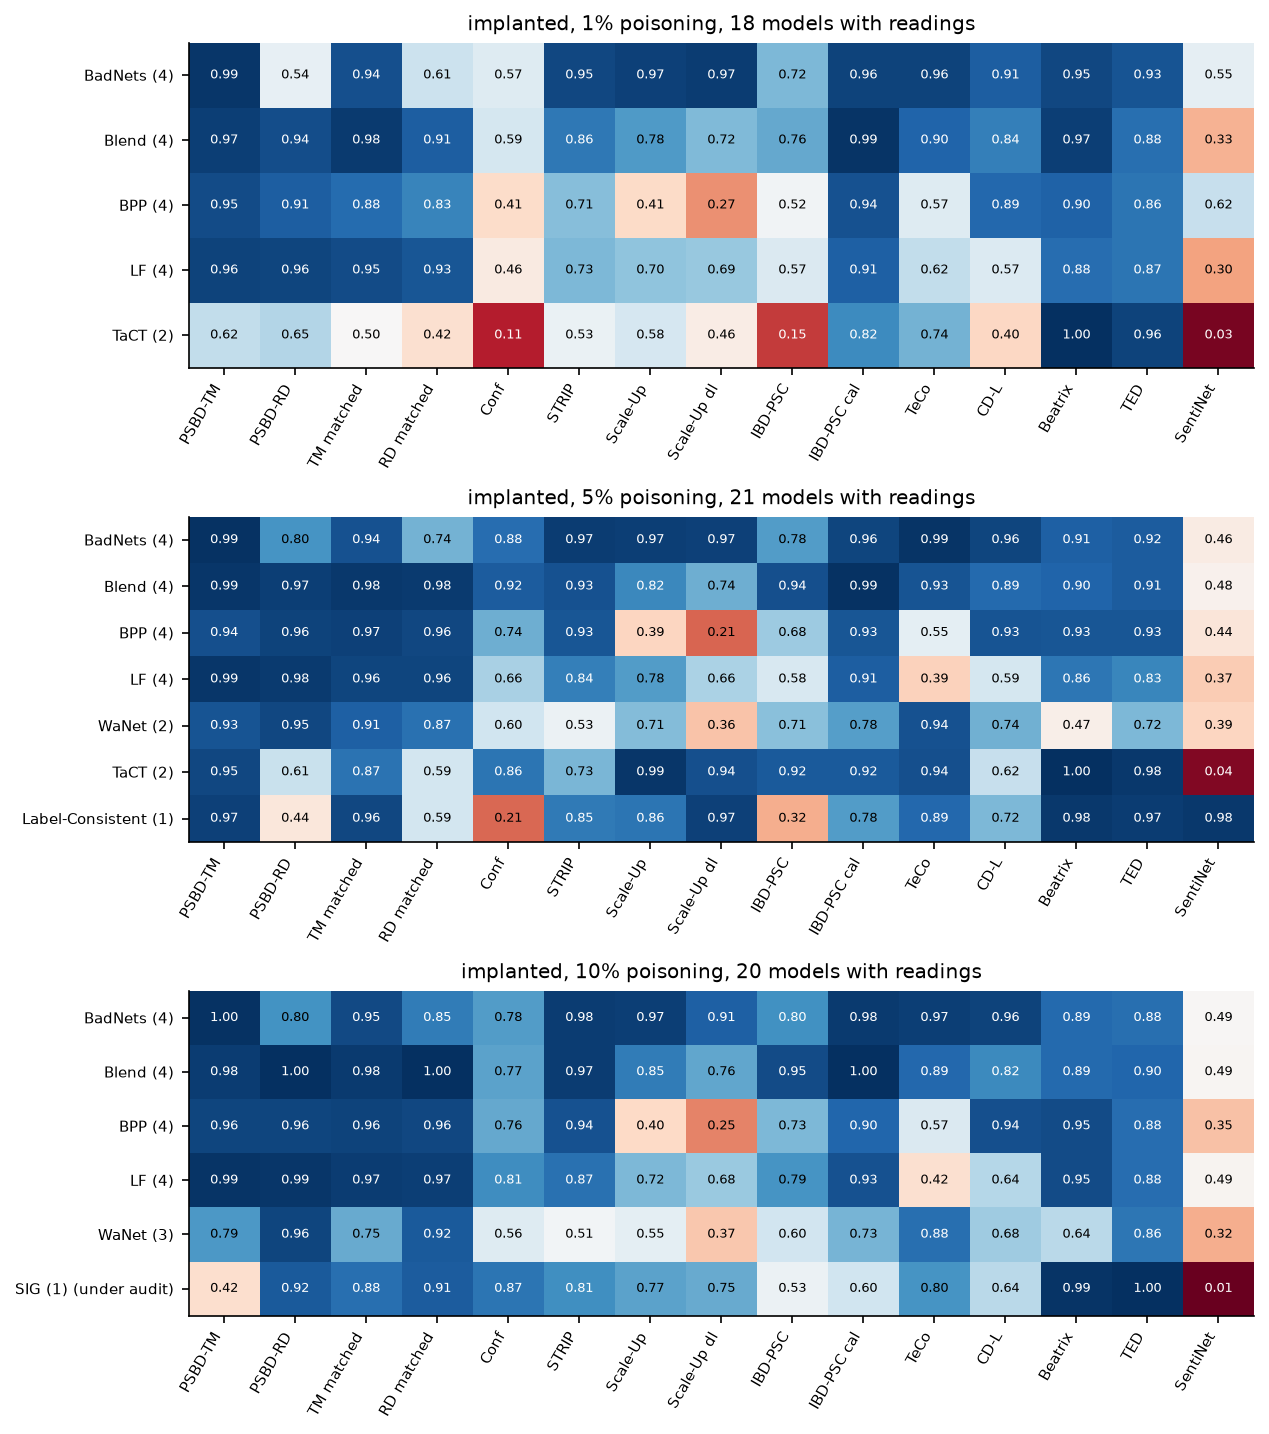

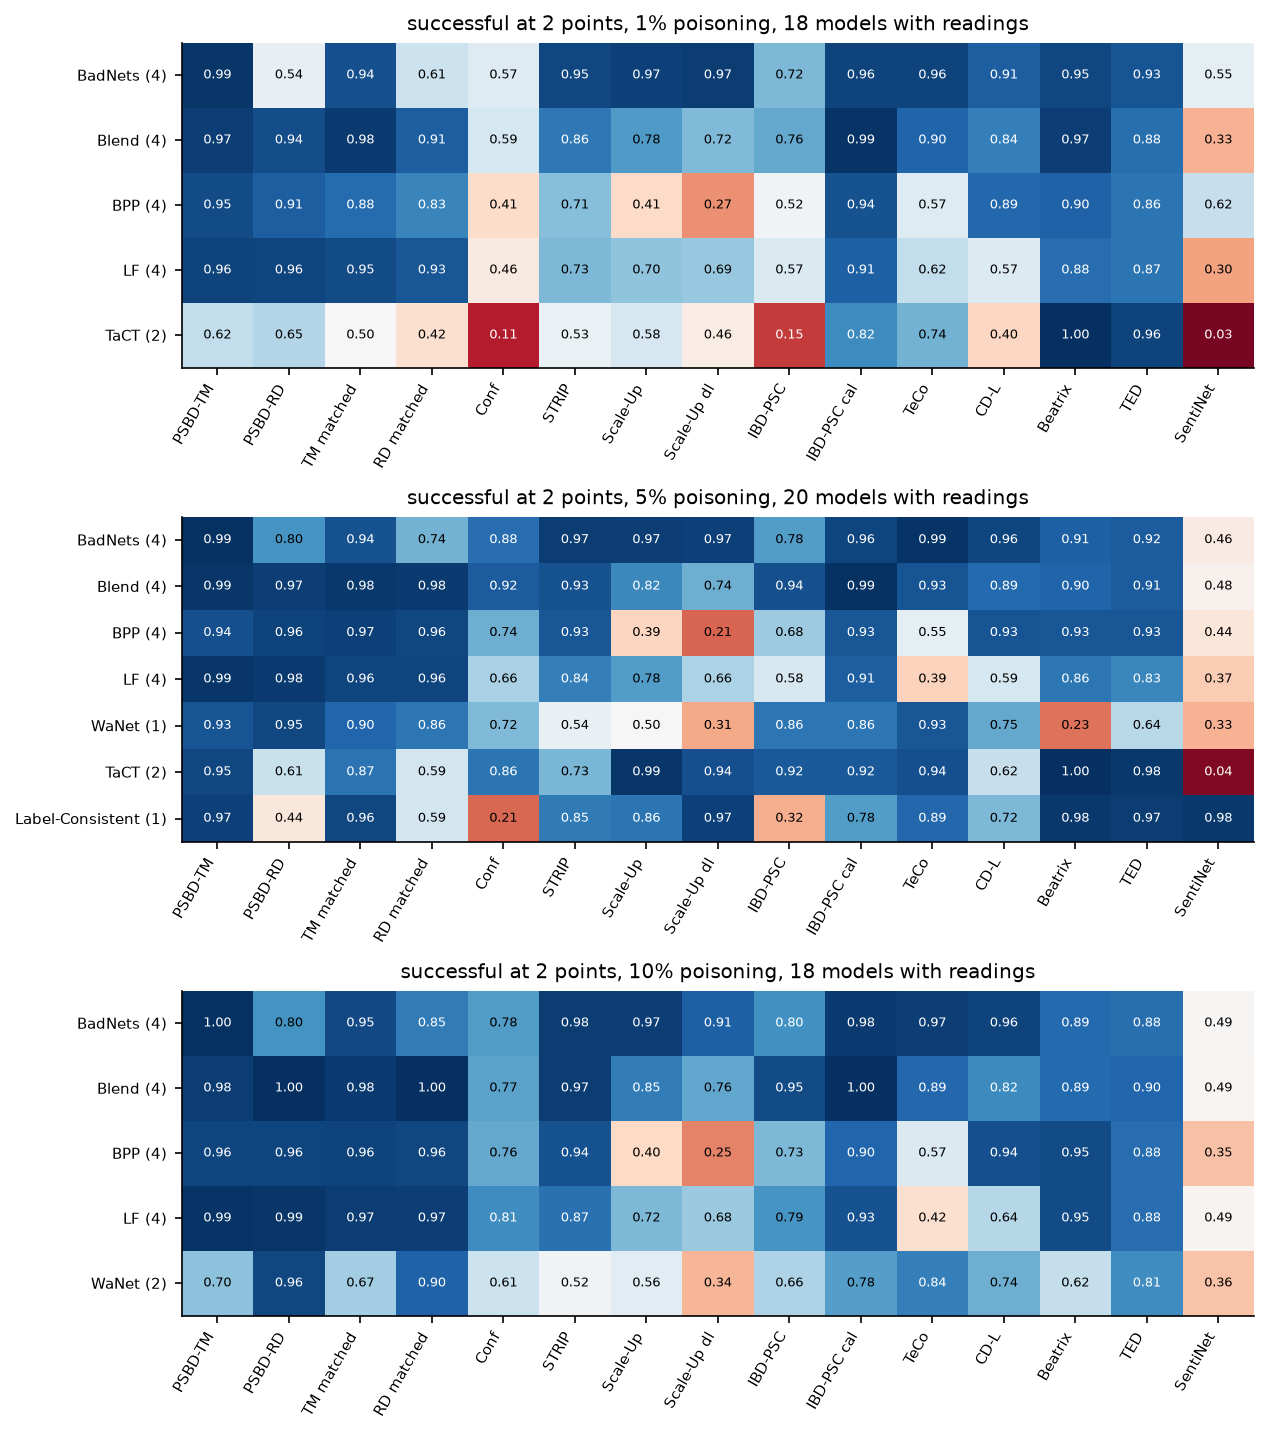

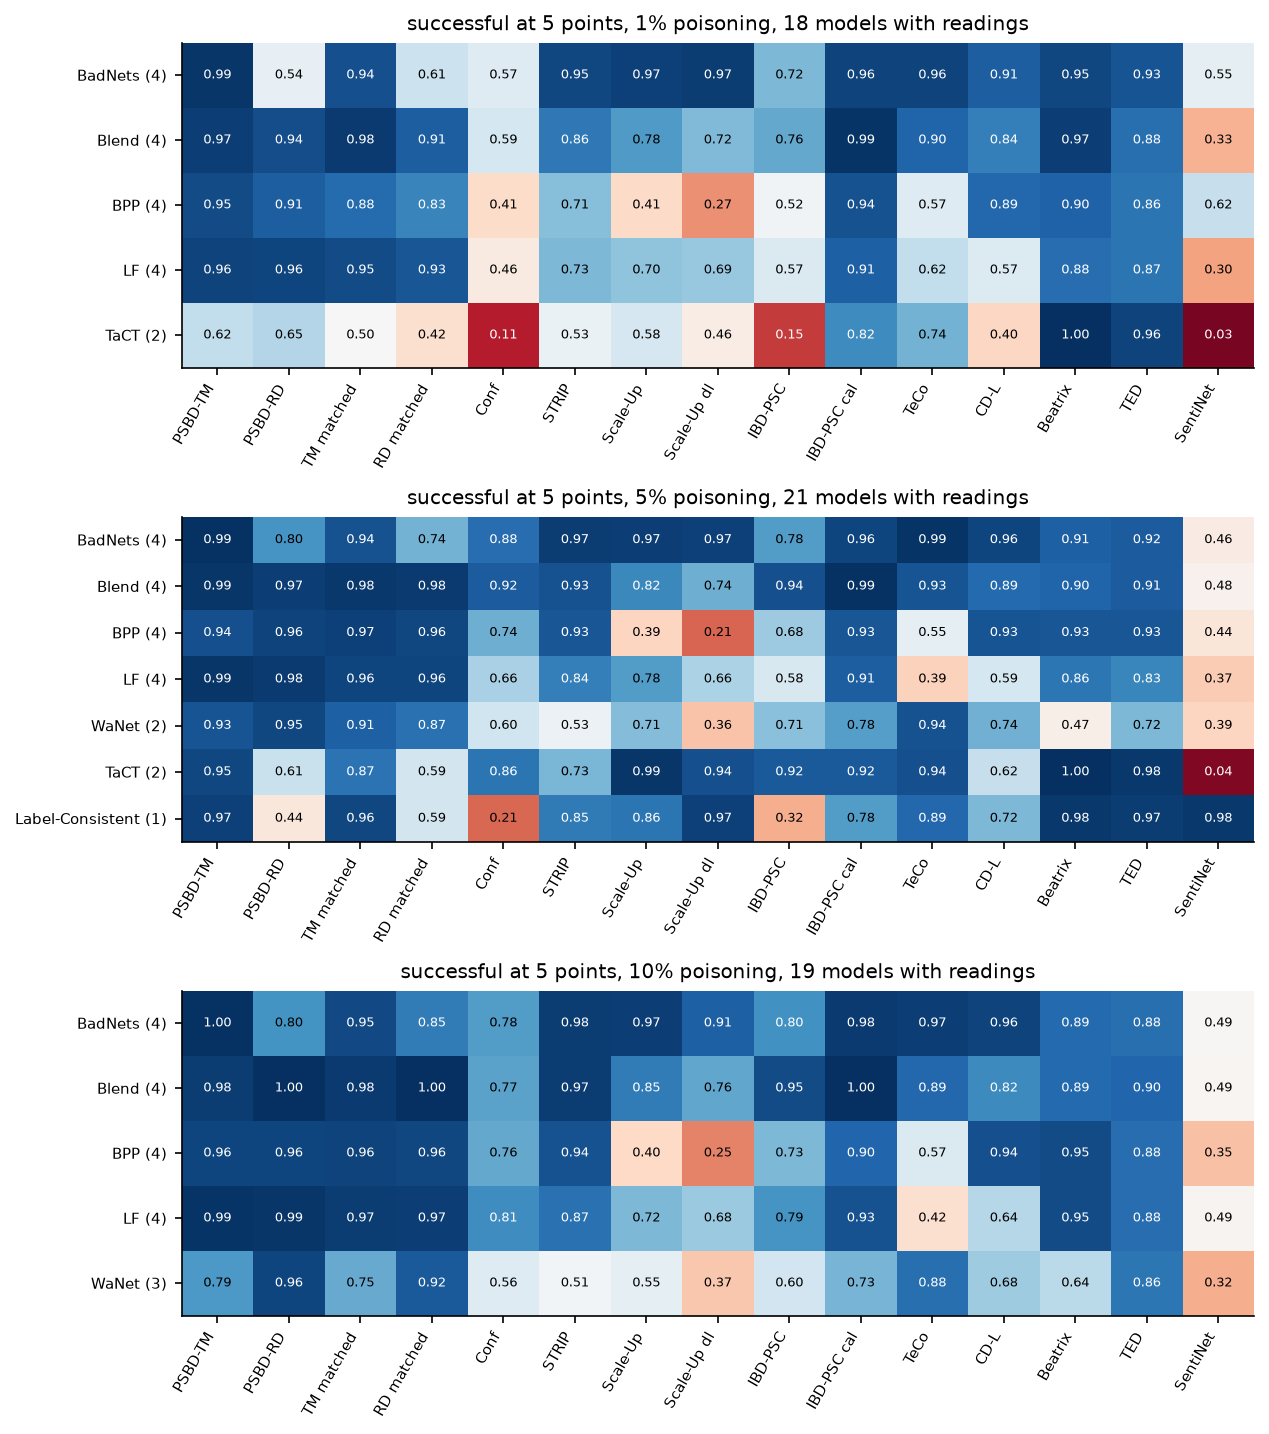

In [10]:
for name, folders in populations.items():
    figure, axes = plt.subplots(len(RATES), 1, figsize=(8.5, 3.2 * len(RATES)))
    for axis, rate in zip(axes, RATES):
        rate_folders = at_rate(folders, rate)
        means, counts_by_attack = cell_means(rate_folders, "auroc", "attack", ATTACK_ORDER)
        draw_heatmap(axis, means, counts_by_attack, attack_label, f"{name}, {rate:.0%} poisoning, {len(rate_folders & carrying)} models with readings")
    plt.tight_layout()
    plt.show()

In [11]:
implanted_means = {rate: cell_means(at_rate(populations["implanted"], rate), "auroc", "attack", ATTACK_ORDER)[0] for rate in RATES}
low_rate, high_rate = RATES[0], RATES[-1]
low_means, high_means = implanted_means[low_rate], implanted_means[high_rate]
rd_low = [attack for attack in low_means.index if low_means.loc[attack, "PSBD-RD"] < 0.65]
# Only the rows where PSBD-TM reads higher carry the gain, so a row where both are low is named apart.
rd_fails = [attack for attack in rd_low if low_means.loc[attack, "PSBD-TM"] > low_means.loc[attack, "PSBD-RD"]]
both_low = [attack for attack in rd_low if attack not in rd_fails]
both_low_rows = [
    f"{attack_label(attack)} ({low_means.loc[attack, 'PSBD-RD']:.2f}, against {low_means.loc[attack, 'PSBD-TM']:.2f} for PSBD-TM)"
    for attack in both_low
]
both_low_text = (
    f" It also reads below 0.65 on {word_list(both_low_rows)}, where PSBD-TM reads lower still."
    if both_low
    else ""
)
rd_leads = [attack for attack in high_means.index if high_means.loc[attack, "PSBD-RD"] > high_means.loc[attack, "PSBD-TM"] + 0.05]
sentinet_below = int((pd.concat(implanted_means.values())["sentinet"] < 0.5).sum())
total_rows = sum(len(frame) for frame in implanted_means.values())
matched_below = int((pd.concat(implanted_means.values())[f"PSBD-TM {MATCHED_SUFFIX}"] < pd.concat(implanted_means.values())["PSBD-TM"]).sum())
say(f'''
On the implanted population at {low_rate:.0%} poisoning PSBD-RD reads at most 0.65 on {word_list(list(f"{attack_label(attack)} ({low_means.loc[attack, 'PSBD-RD']:.2f}, against {low_means.loc[attack, 'PSBD-TM']:.2f} for PSBD-TM)" for attack in rd_fails))}, which is where the paper's gain comes from.{both_low_text} At {high_rate:.0%} PSBD-RD leads PSBD-TM by more than 0.05 on {word_list(list(f"{attack_label(attack)} ({high_means.loc[attack, 'PSBD-RD']:.2f} against {high_means.loc[attack, 'PSBD-TM']:.2f})" for attack in rd_leads))}. The SIG row is marked under audit, and on its single model the PSBD cache and the detector records were also scored on different triggered images (the walkthrough notebook shows this), so on that row the PSBD columns and the competitor columns are not the same comparison. PSBD-TM at the matched rule sits below PSBD-TM at the adaptive rule on {matched_below} of {total_rows} attack rows, since the matched rate is smaller and disturbs the clean model less. SentiNet reads below 0.5 on {sentinet_below} of {total_rows} attack rows, which the paper attributes to its Grad-CAM mask missing the trigger. Across the 3 populations the cells change only where a removed model sat, the SIG row and the WaNet rows. The next figures break the same readings out by dataset.
''')


On the implanted population at 1% poisoning PSBD-RD reads at most 0.65 on BadNets (0.54, against 0.99 for PSBD-TM), which is where the paper's gain comes from. It also reads below 0.65 on TaCT (0.65, against 0.62 for PSBD-TM), where PSBD-TM reads lower still. At 10% PSBD-RD leads PSBD-TM by more than 0.05 on WaNet (0.96 against 0.79) and SIG (0.92 against 0.42). The SIG row is marked under audit, and on its single model the PSBD cache and the detector records were also scored on different triggered images (the walkthrough notebook shows this), so on that row the PSBD columns and the competitor columns are not the same comparison. PSBD-TM at the matched rule sits below PSBD-TM at the adaptive rule on 13 of 18 attack rows, since the matched rate is smaller and disturbs the clean model less. SentiNet reads below 0.5 on 15 of 18 attack rows, which the paper attributes to its Grad-CAM mask missing the trigger. Across the 3 populations the cells change only where a removed model sat, the SIG row and the WaNet rows. The next figures break the same readings out by dataset.


In [12]:
say(f'''
## AUROC per dataset

The left heatmap of each figure is the mean AUROC per dataset and defense over all {len(RATES)} rates, and the right one is the paired gain of PSBD-TM over PSBD-RD per dataset and rate (the per-model difference averaged), red where PSBD-RD leads. The row labels carry the number of models. What to look at: whether PSBD-TM's lead is carried by 1 dataset, and whether a competitor leads on any dataset. A dataset mean pools attacks of different difficulty, so a dataset with more BadNets models looks easier, which the per-attack figures above correct for.
''')


## AUROC per dataset

The left heatmap of each figure is the mean AUROC per dataset and defense over all 3 rates, and the right one is the paired gain of PSBD-TM over PSBD-RD per dataset and rate (the per-model difference averaged), red where PSBD-RD leads. The row labels carry the number of models. What to look at: whether PSBD-TM's lead is carried by 1 dataset, and whether a competitor leads on any dataset. A dataset mean pools attacks of different difficulty, so a dataset with more BadNets models looks easier, which the per-attack figures above correct for.


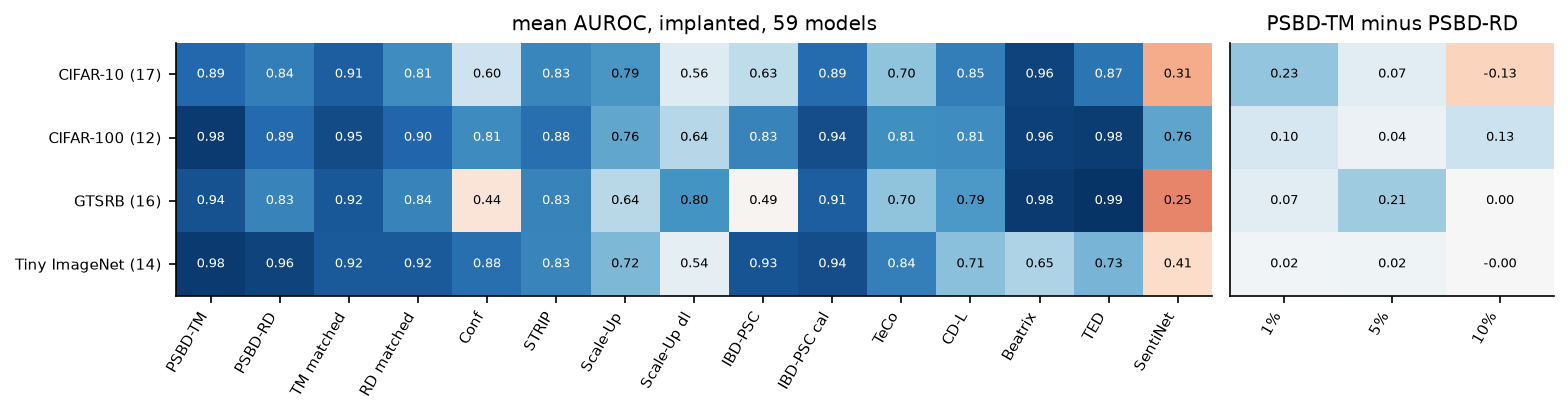

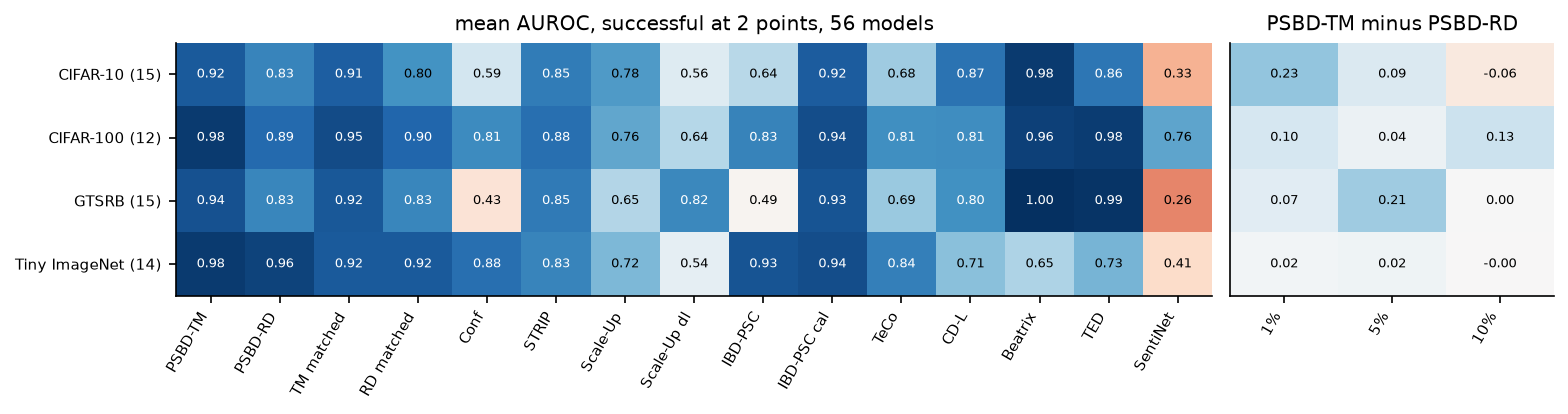

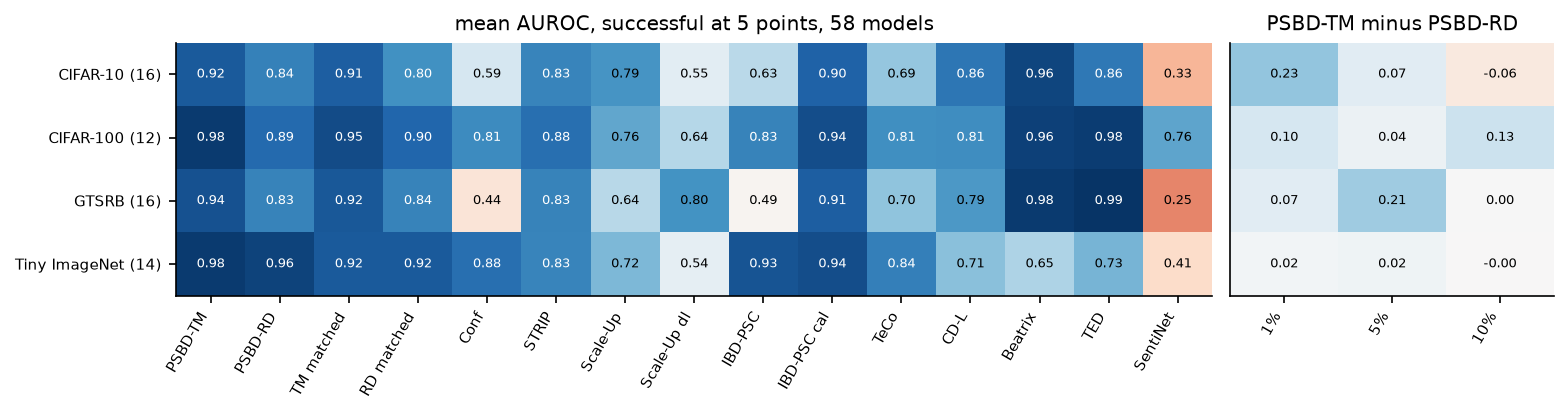


On the headline population the gain of PSBD-TM over PSBD-RD per dataset at 1% is +0.23 on CIFAR-10, +0.10 on CIFAR-100, +0.07 on GTSRB and +0.02 on Tiny ImageNet. At 10% it is -0.06 on CIFAR-10, +0.13 on CIFAR-100, +0.00 on GTSRB and -0.00 on Tiny ImageNet. A competitor's mean AUROC exceeds PSBD-TM's on CIFAR-10 (Beatrix 0.98 against 0.92) and GTSRB (Beatrix 1.00 against 0.94), so the paper's 1st rank is a mean over datasets and not a lead on each. The paper's own sentence on this reads the leaders off the same population: `DetectorsAurocDatasetsOthersLead` is "Beatrix on CIFAR-10 and GTSRB". The next section puts numbers and intervals on these comparisons.


In [13]:
dataset_gains = {}
dataset_means = {}
for name, folders in populations.items():
    figure, (dataset_axis, gain_axis) = plt.subplots(1, 2, figsize=(10.5, 2.8), gridspec_kw={"width_ratios": [3.2, 1]})
    means, counts_by_dataset = cell_means(folders, "auroc", "dataset", DATASETS)
    dataset_means[name] = means
    draw_heatmap(dataset_axis, means, counts_by_dataset, dataset_label, f"mean AUROC, {name}, {len(folders & carrying)} models")
    gains = wide_table(folders, "auroc", ("PSBD-TM", "PSBD-RD")).dropna()
    gains = (gains["PSBD-TM"] - gains["PSBD-RD"]).rename("gain").to_frame().join(vit_meta[["dataset", "poison_rate"]])
    gain_means = gains.pivot_table(index="dataset", columns="poison_rate", values="gain", aggfunc="mean").reindex(DATASETS)
    dataset_gains[name] = gain_means
    gain_means = gain_means.rename(columns=lambda rate: f"{rate:.0%}")
    draw_heatmap(gain_axis, gain_means, gains.dataset.value_counts(), dataset_label, "PSBD-TM minus PSBD-RD", center=0.0, span=0.6)
    gain_axis.set_yticks([])
    plt.tight_layout()
    plt.show()

headline_gains = dataset_gains[HEADLINE_NAME]
headline_means = dataset_means[HEADLINE_NAME]
leaders = {dataset: headline_means.loc[dataset, list(DETECTOR_NAMES)].idxmax() for dataset in headline_means.index}
competitor_leads = [dataset for dataset in headline_means.index if headline_means.loc[dataset, leaders[dataset]] > headline_means.loc[dataset, "PSBD-TM"]]
say(f'''
On the headline population the gain of PSBD-TM over PSBD-RD per dataset at {low_rate:.0%} is {word_list([f"{headline_gains.loc[dataset, low_rate]:+.2f} on {dataset_label(dataset)}" for dataset in headline_gains.index])}. At {high_rate:.0%} it is {word_list([f"{headline_gains.loc[dataset, high_rate]:+.2f} on {dataset_label(dataset)}" for dataset in headline_gains.index])}. A competitor's mean AUROC exceeds PSBD-TM's on {word_list(list(f"{dataset_label(dataset)} ({SHORT[leaders[dataset]]} {headline_means.loc[dataset, leaders[dataset]]:.2f} against {headline_means.loc[dataset, 'PSBD-TM']:.2f})" for dataset in competitor_leads)) or "no dataset"}, so the paper's 1st rank is a mean over datasets and not a lead on each. The paper's own sentence on this reads the leaders off the same population: `DetectorsAurocDatasetsOthersLead` is "{macro("DetectorsAurocDatasetsOthersLead")}". The next section puts numbers and intervals on these comparisons.
''')

In [14]:
say(f'''
## PSBD-TM, PSBD-RD and the best competitor

For each population and each poison rate the table gives these columns.

- `n`, the number of models.
- The mean AUROC of PSBD-TM, of PSBD-RD and of the competitor with the highest mean AUROC in that subset.
- `TM - RD`, the paired gain of PSBD-TM over PSBD-RD with its 95% bootstrap interval.
- `TM - competitor`, the paired margin of PSBD-TM over that best competitor with its interval.
- The mean TPR of the 3 at the {BUDGETS[0]:.2f} and {BUDGETS[1]:.2f} budgets.

The best competitor is chosen per subset, so it can change between rows. Choosing it after seeing the data makes the margin conservative for PSBD-TM. The bootstrap draws positions in a list of models, so under the fixed seed an interval depends on the order the models are listed in, at the third decimal. The gain interval is taken in folder name order, the order `scripts/paper/tab_headline.py` iterates in. The margin interval is taken in dataset, attack and rate order, the order `scripts/paper/tab_detectors.py` iterates in. Those 2 orders reproduce both of the paper's intervals exactly.

The scatter plots after the table place every model of the headline population by its PSBD-RD AUROC (left) or its IBD-PSC cal AUROC (right, the calibrated IBD-PSC port) on the horizontal axis and its PSBD-TM AUROC on the vertical axis, colored by poison rate. A point above the diagonal is a model where PSBD-TM wins.
''')


## PSBD-TM, PSBD-RD and the best competitor

For each population and each poison rate the table gives these columns.

- `n`, the number of models.
- The mean AUROC of PSBD-TM, of PSBD-RD and of the competitor with the highest mean AUROC in that subset.
- `TM - RD`, the paired gain of PSBD-TM over PSBD-RD with its 95% bootstrap interval.
- `TM - competitor`, the paired margin of PSBD-TM over that best competitor with its interval.
- The mean TPR of the 3 at the 0.10 and 0.20 budgets.

The best competitor is chosen per subset, so it can change between rows. Choosing it after seeing the data makes the margin conservative for PSBD-TM. The bootstrap draws positions in a list of models, so under the fixed seed an interval depends on the order the models are listed in, at the third decimal. The gain interval is taken in folder name order, the order `scripts/paper/tab_headline.py` iterates in. The margin interval is taken in dataset, attack and rate order, the order `scripts/paper/tab_detectors.py` iterates in. Those 2 orders reproduce both of the paper's intervals exactly.

The scatter plots after the table place every model of the headline population by its PSBD-RD AUROC (left) or its IBD-PSC cal AUROC (right, the calibrated IBD-PSC port) on the horizontal axis and its PSBD-TM AUROC on the vertical axis, colored by poison rate. A point above the diagonal is a model where PSBD-TM wins.


In [15]:
def comparison_row(folders, label):
    wide = wide_table(folders, "auroc").dropna(subset=["PSBD-TM", "PSBD-RD", *DETECTOR_NAMES])
    kept = set(wide.index)
    competitors = wide[list(DETECTOR_NAMES)].mean()
    best = competitors.idxmax()
    gain, gain_low, gain_high, _ = paired_interval(kept, "PSBD-TM", "PSBD-RD", order_by="folder")
    margin, margin_low, margin_high, _ = paired_interval(kept, "PSBD-TM", best)
    budget_tables = {budget: wide_table(kept, f"tpr_q{budget:.2f}") for budget in BUDGETS}
    row = {
        "subset": label,
        "n": len(kept),
        "PSBD-TM": wide["PSBD-TM"].mean(),
        "PSBD-RD": wide["PSBD-RD"].mean(),
        "best competitor": SHORT[best],
        "competitor AUROC": competitors[best],
        "TM - RD": f"{gain:+.3f} [{gain_low:+.3f}, {gain_high:+.3f}]",
        "TM - competitor": f"{margin:+.3f} [{margin_low:+.3f}, {margin_high:+.3f}]",
    }
    for budget, frame in budget_tables.items():
        row[f"TPR@{budget:.2f} TM"] = frame["PSBD-TM"].mean()
        row[f"TPR@{budget:.2f} RD"] = frame["PSBD-RD"].mean()
        row[f"TPR@{budget:.2f} competitor"] = frame[best].mean()
    return row


comparison = []
for name, folders in populations.items():
    comparison.append(comparison_row(folders, f"{name}, all rates"))
    for rate in RATES:
        comparison.append(comparison_row(at_rate(folders, rate), f"{name}, {rate:.0%}"))
comparison = pd.DataFrame(comparison).set_index("subset")
display(comparison)

,n,PSBD-TM,PSBD-RD,best competitor,competitor AUROC,TM - RD,TM - competitor,TPR@0.10 TM,TPR@0.10 RD,TPR@0.10 competitor,TPR@0.20 TM,TPR@0.20 RD,TPR@0.20 competitor
subset,,,,,,,,,,,,,
"implanted, all rates",59,0.941,0.879,IBD-PSC cal,0.918,"+0.062 [+0.005, +0.122]","+0.023 [-0.012, +0.054]",0.859,0.730,0.776,0.888,0.793,0.863
"implanted, 1%",18,0.929,0.818,Beatrix,0.935,"+0.111 [-0.023, +0.246]","-0.006 [-0.110, +0.074]",0.828,0.633,0.704,0.852,0.718,0.769
"implanted, 5%",21,0.970,0.876,IBD-PSC cal,0.921,"+0.093 [+0.027, +0.172]","+0.049 [+0.010, +0.088]",0.879,0.691,0.766,0.912,0.759,0.856
"implanted, 10%",20,0.922,0.937,IBD-PSC cal,0.901,"-0.015 [-0.104, +0.073]","+0.021 [-0.032, +0.074]",0.867,0.858,0.757,0.894,0.896,0.828
"successful at 2 points, all rates",56,0.951,0.876,IBD-PSC cal,0.933,"+0.075 [+0.017, +0.138]","+0.018 [-0.017, +0.048]",0.872,0.722,0.808,0.900,0.785,0.892
"successful at 2 points, 1%",18,0.929,0.818,Beatrix,0.935,"+0.111 [-0.023, +0.246]","-0.006 [-0.110, +0.074]",0.828,0.633,0.704,0.852,0.718,0.769
"successful at 2 points, 5%",20,0.972,0.872,IBD-PSC cal,0.932,"+0.099 [+0.030, +0.183]","+0.039 [+0.003, +0.075]",0.881,0.681,0.795,0.912,0.748,0.881
"successful at 2 points, 10%",18,0.949,0.937,IBD-PSC cal,0.932,"+0.012 [-0.065, +0.097]","+0.017 [-0.028, +0.061]",0.906,0.856,0.821,0.935,0.893,0.888
"successful at 5 points, all rates",58,0.950,0.879,IBD-PSC cal,0.924,"+0.072 [+0.017, +0.132]","+0.027 [-0.009, +0.057]",0.873,0.729,0.787,0.901,0.791,0.872


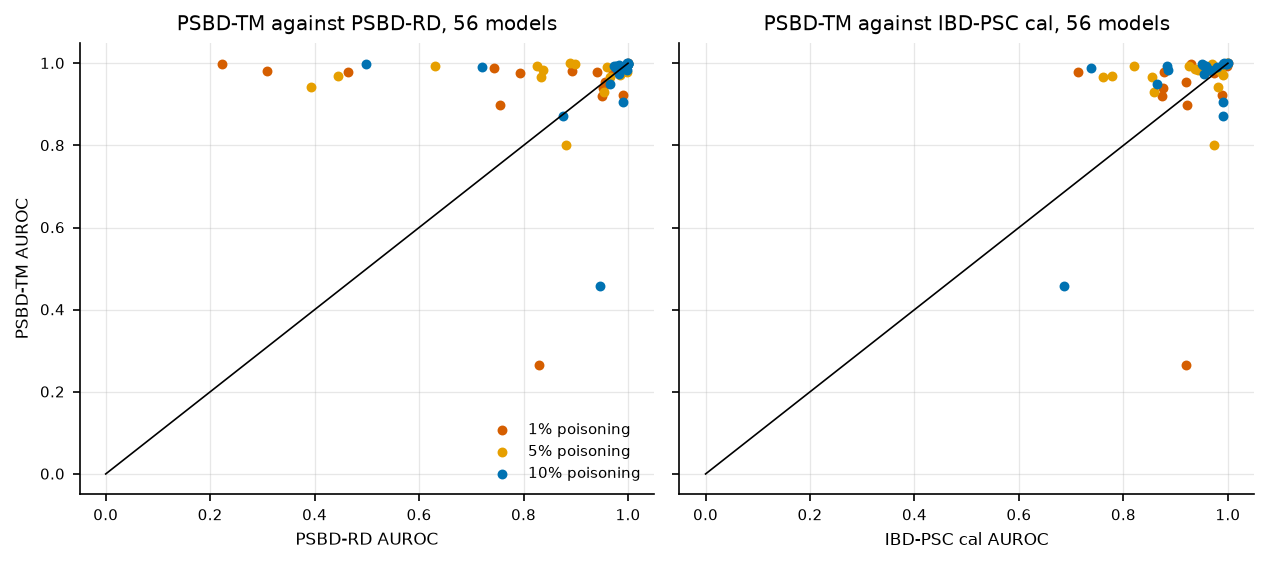


The successful at 2 points row reproduces the paper's headline: PSBD-TM 0.951 (macro `HeadlineAurocAdaptive` 0.951), PSBD-RD 0.876 (`PublishedAurocAdaptive` 0.876), a gain of +0.075 [+0.017, +0.138] (`HeadlineGainAdaptiveAuroc` +0.075 [+0.017, +0.138]) and a margin of +0.018 [-0.017, +0.048] over IBD-PSC cal (`DetectorsAurocMargin` +0.018 [$-$0.017, +0.048]), on 56 models. The successful at 5 points row reproduces the second-bar macros: PSBD-TM 0.950 (`HeadlineAurocAdaptiveFivePoint` 0.950), PSBD-RD 0.879 (`PublishedAurocAdaptiveFivePoint` 0.879), a gain of +0.072 [+0.017, +0.132] (`HeadlineGainAdaptiveAurocFivePoint` +0.072) and a margin of +0.027 [-0.009, +0.057] (`DetectorsAurocMarginFivePoint` +0.027), on 58 models. On the implanted population, 59 models whatever their clean accuracy, PSBD-TM reads 0.941 and PSBD-RD 0.879, a gain of +0.062 [+0.005, +0.122] and a margin of +0.023 [-0.012, +0.054] over IBD-PSC cal. The gain of PSBD-TM over PSBD-RD falls from the lowest to the highest poison rate in every population (implanted: +0.111, +0.093 and -0.015, then successful at 2 points: +0.111, +0.099 and +0.012, then successful at 5 points: +0.111, +0.093 and +0.011). The scatter shows the same per model: most points sit on the diagonal against both PSBD-RD and IBD-PSC cal, and the mean is carried by a few models far above it. The next section asks how every other PSBD placement compares.


In [16]:
headline = populations[HEADLINE_NAME]
wide = wide_table(headline, "auroc").dropna(subset=["PSBD-TM"])
colors = dict(zip(RATES, ("#D55E00", "#E69F00", "#0072B2")))
figure, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), sharey=True)
for axis, other in zip(axes, ("PSBD-RD", "ibd_psc_calibrated")):
    for rate, color in colors.items():
        rate_folders = [folder for folder in wide.index if vit_meta.poison_rate[folder] == rate]
        axis.scatter(wide.loc[rate_folders, other], wide.loc[rate_folders, "PSBD-TM"], s=14, color=color, label=f"{rate:.0%} poisoning")
    axis.plot([0, 1], [0, 1], color="black", linewidth=0.8)
    axis.set_xlabel(f"{SHORT[other]} AUROC")
    axis.set_title(f"PSBD-TM against {SHORT[other]}, {len(wide)} models")
axes[0].set_ylabel("PSBD-TM AUROC")
axes[0].legend()
plt.tight_layout()
plt.show()

def gain_mean(label):
    mean = float(comparison.loc[label, "TM - RD"].split(" ")[0])
    return mean


gain_series = {name: [gain_mean(f"{name}, {rate:.0%}") for rate in RATES] for name in populations}
shrinking = all(values == sorted(values, reverse=True) for values in gain_series.values())
gain_by_rate = "; ".join(f"{name}: " + word_list(list(f"{value:+.3f}" for value in values)) for name, values in gain_series.items()).replace("; ", ", then ")
implanted_row = comparison.loc["implanted, all rates"]
headline_row = comparison.loc[f"{HEADLINE_NAME}, all rates"]
second_row = comparison.loc[f"{SECOND_NAME}, all rates"]
say(f'''
The {HEADLINE_NAME} row reproduces the paper's headline: PSBD-TM {headline_row["PSBD-TM"]:.3f} (macro `HeadlineAurocAdaptive` {macro("HeadlineAurocAdaptive")}), PSBD-RD {headline_row["PSBD-RD"]:.3f} (`PublishedAurocAdaptive` {macro("PublishedAurocAdaptive")}), a gain of {headline_row["TM - RD"]} (`HeadlineGainAdaptiveAuroc` {macro("HeadlineGainAdaptiveAuroc")} [{macro("HeadlineGainAdaptiveAurocLow")}, {macro("HeadlineGainAdaptiveAurocHigh")}]) and a margin of {headline_row["TM - competitor"]} over {headline_row["best competitor"]} (`DetectorsAurocMargin` {macro("DetectorsAurocMargin")} [{macro("DetectorsAurocMarginLow")}, {macro("DetectorsAurocMarginHigh")}]), on {headline_row["n"]} models. The {SECOND_NAME} row reproduces the second-bar macros: PSBD-TM {second_row["PSBD-TM"]:.3f} (`HeadlineAurocAdaptiveFivePoint` {macro("HeadlineAurocAdaptiveFivePoint")}), PSBD-RD {second_row["PSBD-RD"]:.3f} (`PublishedAurocAdaptiveFivePoint` {macro("PublishedAurocAdaptiveFivePoint")}), a gain of {second_row["TM - RD"]} (`HeadlineGainAdaptiveAurocFivePoint` {macro("HeadlineGainAdaptiveAurocFivePoint")}) and a margin of {second_row["TM - competitor"]} (`DetectorsAurocMarginFivePoint` {macro("DetectorsAurocMarginFivePoint")}), on {second_row["n"]} models. On the implanted population, {implanted_row["n"]} models whatever their clean accuracy, PSBD-TM reads {implanted_row["PSBD-TM"]:.3f} and PSBD-RD {implanted_row["PSBD-RD"]:.3f}, a gain of {implanted_row["TM - RD"]} and a margin of {implanted_row["TM - competitor"]} over {implanted_row["best competitor"]}. The gain of PSBD-TM over PSBD-RD {"falls" if shrinking else "does not fall"} from the lowest to the highest poison rate in every population ({gain_by_rate}). The scatter shows the same per model: most points sit on the diagonal against both PSBD-RD and IBD-PSC cal, and the mean is carried by a few models far above it. The next section asks how every other PSBD placement compares.
''')

In [17]:
say(f'''
## Every PSBD placement at the adaptive rule

`psbd_metrics.json` holds every placement ever swept on a model: the {len(declaration["basis"])} placements declared in `configs/psbd_basis.json` plus variants (other mask seeds with `_seed`, other pass counts with `_k`, the model's own dropout with `_pmodel`). The chart gives, for the headline population, the mean AUROC of every placement at the adaptive rule over the models where that placement has a reading, with the number of models in the label. The table beside it adds the paired gain over PSBD-RD computed on the models carrying both. Coverage differs between placements, so 2 bars with different counts are means over different models. Only the paired gain column compares like with like. A placement whose ladder never reaches a shift ratio of {ADAPTIVE_SHIFT_TARGET} on a model has no adaptive reading there. The `unreached` column counts those models, because leaving them out silently would flatter a weak placement. What this does not show is any placement at its best rate, since the adaptive rule is the only rule used.
''')


## Every PSBD placement at the adaptive rule

`psbd_metrics.json` holds every placement ever swept on a model: the 27 placements declared in `configs/psbd_basis.json` plus variants (other mask seeds with `_seed`, other pass counts with `_k`, the model's own dropout with `_pmodel`). The chart gives, for the headline population, the mean AUROC of every placement at the adaptive rule over the models where that placement has a reading, with the number of models in the label. The table beside it adds the paired gain over PSBD-RD computed on the models carrying both. Coverage differs between placements, so 2 bars with different counts are means over different models. Only the paired gain column compares like with like. A placement whose ladder never reaches a shift ratio of 0.8 on a model has no adaptive reading there. The `unreached` column counts those models, because leaving them out silently would flatter a weak placement. What this does not show is any placement at its best rate, since the adaptive rule is the only rule used.


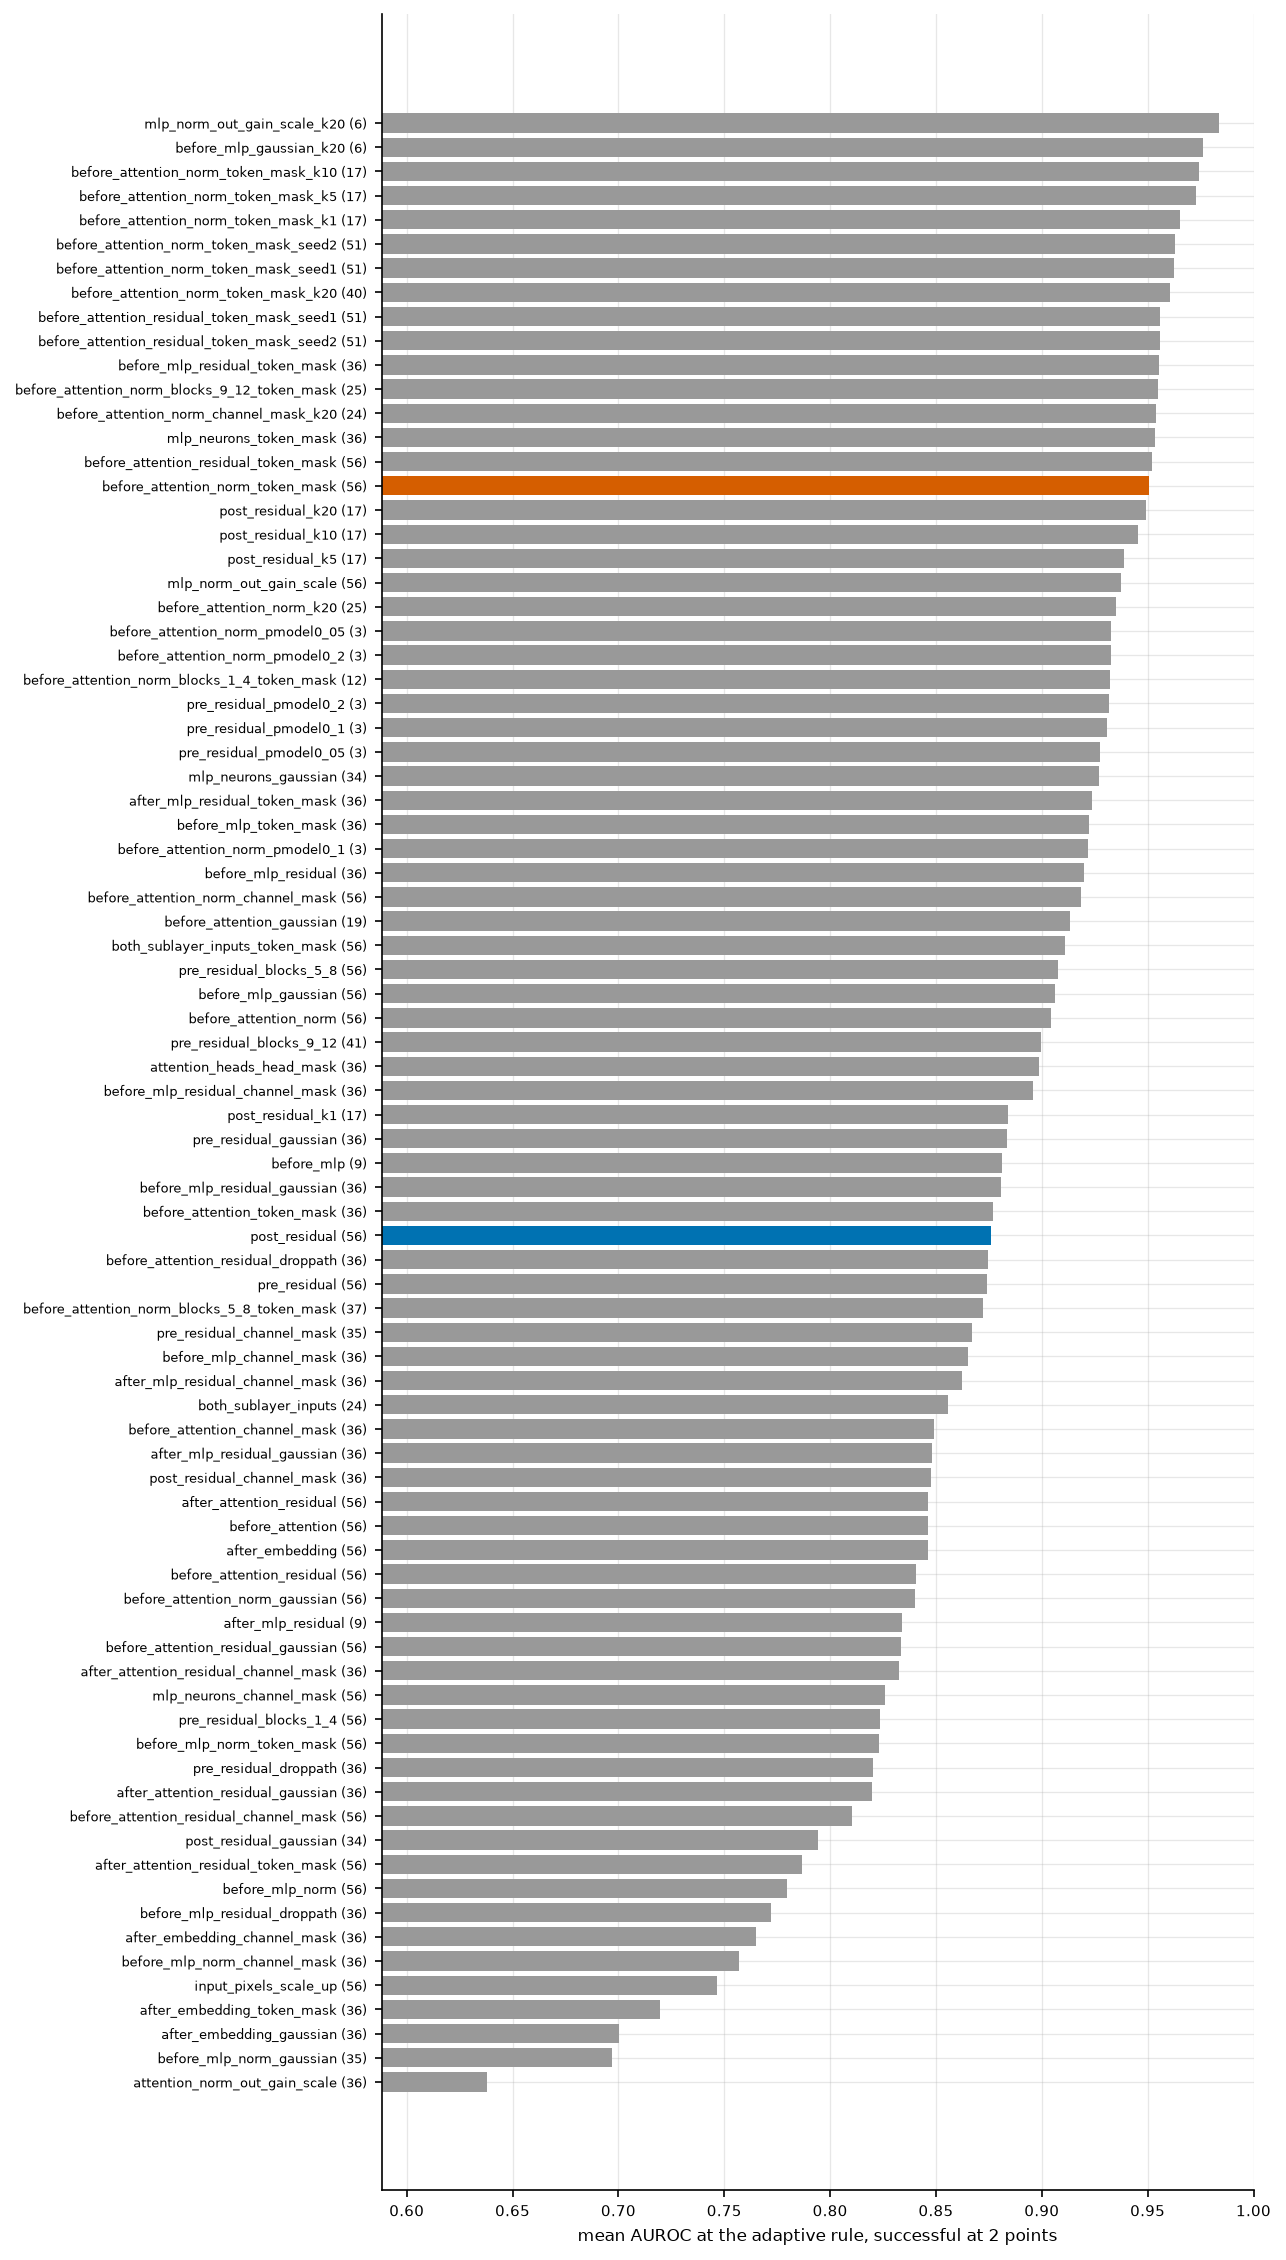

,mean,count,unreached,paired n,gain over PSBD-RD,low,high
placement,,,,,,,
mlp_norm_out_gain_scale_k20,0.984,6,0,6,0.095,0.020,0.180
before_mlp_gaussian_k20,0.976,6,0,6,0.088,0.022,0.171
before_attention_norm_token_mask_k10,0.974,17,0,17,0.044,0.008,0.088
before_attention_norm_token_mask_k5,0.973,17,0,17,0.043,0.007,0.086
before_attention_norm_token_mask_k1,0.965,17,0,17,0.036,0.002,0.076
before_attention_norm_token_mask_seed2,0.963,51,0,51,0.059,0.012,0.112
before_attention_norm_token_mask_seed1,0.962,51,0,51,0.059,0.012,0.111
before_attention_norm_token_mask_k20,0.961,40,0,40,0.089,0.027,0.158
before_attention_residual_token_mask_seed1,0.956,51,0,51,0.052,0.004,0.106



Among the 23 placements read on all 56 models of the population, the highest means are `before_attention_residual_token_mask` 0.952, `before_attention_norm_token_mask` 0.951 and `mlp_norm_out_gain_scale` 0.938. PSBD-RD (`post_residual`) reads 0.876, rank 9 of 23. The 15 bars above PSBD-TM overall are all read on fewer models (6, 17, 24, 25, 36, 40, 51 and 56), mostly more-pass variants, so they are means over a different and smaller set of models. The paired gain column is the comparison to read. The next section repeats the headline comparison on Swin-S.


In [18]:
psbd_rows = rows[(rows.architecture == "vit") & rows.folder_name.isin(headline) & (rows.family == "psbd") & (rows.rule == "adaptive")]
scored = psbd_rows[psbd_rows.status == "scored"]
placements = scored.groupby("placement").auroc.agg(["mean", "count"])
placements["unreached"] = psbd_rows[psbd_rows.status == "shift_target_unreached"].groupby("placement").size().reindex(placements.index).fillna(0).astype(int)
rd = scored[scored.placement == PUBLISHED_PLACEMENT].set_index("folder_name").auroc
gain_rows = []
for placement, group in scored.groupby("placement"):
    paired = group.set_index("folder_name").auroc.to_frame("placement").join(rd.rename("rd"), how="inner").sort_index()
    differences = (paired["placement"] - paired["rd"]).tolist()
    low, high = bootstrap_ci(differences, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    gain_rows.append({"placement": placement, "paired n": len(differences), "gain over PSBD-RD": float(np.mean(differences)), "low": low, "high": high})
placements = placements.join(pd.DataFrame(gain_rows).set_index("placement")).sort_values("mean", ascending=False)

figure, axis = plt.subplots(figsize=(7.5, 0.22 * len(placements) + 0.8))
colors = ["#D55E00" if name == RECOMMENDED_PLACEMENT else "#0072B2" if name == PUBLISHED_PLACEMENT else "#999999" for name in placements.index]
axis.barh(np.arange(len(placements)), placements["mean"], color=colors)
axis.set_yticks(np.arange(len(placements)), [f"{name} ({count})" for name, count in zip(placements.index, placements["count"])], fontsize=6)
axis.invert_yaxis()
axis.axvline(0.5, color="black", linewidth=0.8, linestyle=":")
axis.set_xlim(max(0.0, float(placements["mean"].min()) - 0.05), 1.0)
axis.set_xlabel(f"mean AUROC at the adaptive rule, {HEADLINE_NAME}")
plt.show()
display(placements.round(3))

full_coverage = placements["count"].max()
full = placements[placements["count"] == full_coverage].sort_values("mean", ascending=False)
above = placements[(placements["mean"] > placements.loc[RECOMMENDED_PLACEMENT, "mean"])]
say(f'''
Among the {len(full)} placements read on all {full_coverage} models of the population, the highest means are {word_list([f"`{name}` {value:.3f}" for name, value in full["mean"].head(3).items()])}. PSBD-RD (`{PUBLISHED_PLACEMENT}`) reads {placements.loc[PUBLISHED_PLACEMENT, "mean"]:.3f}, rank {list(full.index).index(PUBLISHED_PLACEMENT) + 1} of {len(full)}. The {len(above)} bars above PSBD-TM overall are all read on fewer models ({word_list(list(sorted({str(count) for count in above["count"]}, key=int)))}), mostly more-pass variants, so they are means over a different and smaller set of models. The paired gain column is the comparison to read. The next section repeats the headline comparison on Swin-S.
''')

In [19]:
swin_models = models[models.architecture == "swin"].copy()
swin_meta = swin_models.set_index("folder_name")
swin_rows = rows[(rows.architecture == "swin") & (rows.kind == "attack") & (rows.status == "scored")]
swin_panel = swin_models[swin_models.in_panel & (swin_models.kind == "attack")]
swin_populations = {
    "implanted": set(swin_panel[swin_panel.asr_class == "clears"].folder_name),
    HEADLINE_NAME: set(swin_panel[swin_panel.successful_2pt.astype(bool)].folder_name),
    SECOND_NAME: set(swin_panel[swin_panel.successful_5pt.astype(bool)].folder_name),
}
swin_failing = swin_panel[(swin_panel.asr_class == "clears") & ~swin_panel.successful_2pt.astype(bool)]
swin_failing_words = word_list(list(f"`{row.folder_name}` (clean accuracy {row.clean_accuracy_drop:+.3f} against the benign model)" for row in swin_failing.itertuples()))
say(f'''
## Swin-S

Swin-S is the second architecture, used to test whether the placement ranking transfers. No detector records exist for Swin, so only PSBD placements are compared. Swin follows exactly the ViT panel rule: `scripts.paper._common.swin_coverage` applies the declaration to the Swin checkpoints with Swin's own benign references and builds the ledger in memory with the same `asr_class` and success verdicts, and `scripts/paper/tab_swin.py` reads its {HEADLINE_NAME} models. The rule holds {len(swin_panel)} Swin models, {word_list(list(f"{count} `{name}`" for name, count in swin_panel.asr_class.value_counts().items()))}, and the headline bar leaves out {swin_failing_words}.

The paper's Swin macros are `SwinRecommendedAurocAdaptive` {macro("SwinRecommendedAurocAdaptive")} over `SwinRecommendedN` {macro("SwinRecommendedN")} models and `SwinPublishedAurocAdaptive` {macro("SwinPublishedAurocAdaptive")} over `SwinCells` {macro("SwinCells")}, on the {HEADLINE_NAME} population, and `SwinRecommendedAurocAdaptiveFivePoint` {macro("SwinRecommendedAurocAdaptiveFivePoint")} on the {SECOND_NAME} one.
''')

summary = []
for name, folders in swin_populations.items():
    wide = swin_rows[swin_rows.folder_name.isin(folders) & swin_rows.defense.isin(["PSBD-TM", "PSBD-RD"])].pivot(index="folder_name", columns="defense", values="auroc")
    paired = wide.dropna().sort_index()
    differences = (paired["PSBD-TM"] - paired["PSBD-RD"]).tolist()
    low, high = bootstrap_ci(differences, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
    tpr = swin_rows[swin_rows.folder_name.isin(folders) & swin_rows.defense.isin(["PSBD-TM", "PSBD-RD"])].pivot(index="folder_name", columns="defense", values=f"tpr_q{BUDGETS[0]:.2f}")
    summary.append({"selection": name, "models": len(folders), "PSBD-TM n": int(wide["PSBD-TM"].notna().sum()), "PSBD-TM": wide["PSBD-TM"].mean(), "PSBD-RD n": int(wide["PSBD-RD"].notna().sum()), "PSBD-RD": wide["PSBD-RD"].mean(), "paired n": len(differences), "TM - RD": f"{np.mean(differences):+.3f} [{low:+.3f}, {high:+.3f}]", f"TPR@{BUDGETS[0]:.2f} TM": tpr["PSBD-TM"].mean(), f"TPR@{BUDGETS[0]:.2f} RD": tpr["PSBD-RD"].mean()})
swin_summary = pd.DataFrame(summary).set_index("selection")
display(swin_summary)


## Swin-S

Swin-S is the second architecture, used to test whether the placement ranking transfers. No detector records exist for Swin, so only PSBD placements are compared. Swin follows exactly the ViT panel rule: `scripts.paper._common.swin_coverage` applies the declaration to the Swin checkpoints with Swin's own benign references and builds the ledger in memory with the same `asr_class` and success verdicts, and `scripts/paper/tab_swin.py` reads its successful at 2 points models. The rule holds 93 Swin models, 66 `clears`, 19 `below_bar` and 8 `source_mapped`, and the headline bar leaves out `swin_cifar10_sig_0_1` (clean accuracy -0.100 against the benign model).

The paper's Swin macros are `SwinRecommendedAurocAdaptive` 0.973 over `SwinRecommendedN` 63 models and `SwinPublishedAurocAdaptive` 0.881 over `SwinCells` 65, on the successful at 2 points population, and `SwinRecommendedAurocAdaptiveFivePoint` 0.973 on the successful at 5 points one.


,models,PSBD-TM n,PSBD-TM,PSBD-RD n,PSBD-RD,paired n,TM - RD,TPR@0.10 TM,TPR@0.10 RD
selection,,,,,,,,,
implanted,66,64,0.972,66,0.881,64,"+0.094 [+0.051, +0.141]",0.938,0.676
successful at 2 points,65,63,0.973,65,0.881,63,"+0.096 [+0.051, +0.144]",0.939,0.674
successful at 5 points,65,63,0.973,65,0.881,63,"+0.096 [+0.051, +0.144]",0.939,0.674


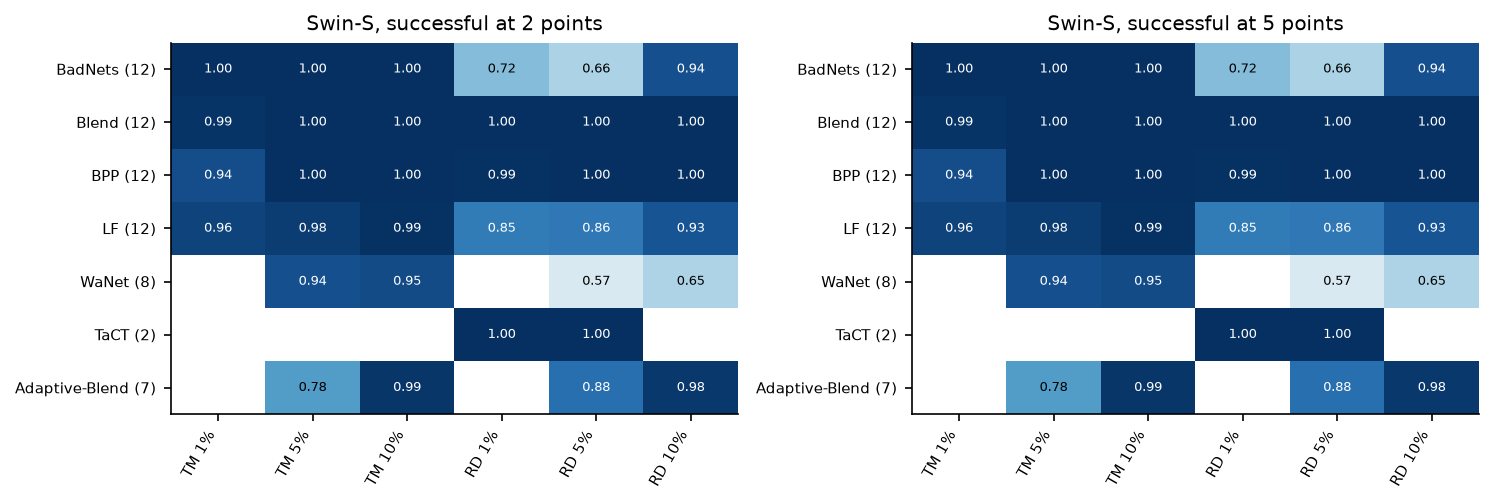


The summary table reproduces the paper's Swin numbers on the successful at 2 points population, PSBD-TM 0.973 over 63 models and PSBD-RD 0.881 over 65, a paired gain of +0.096 [+0.051, +0.144], and gives the successful at 5 points population beside it, PSBD-TM 0.973 and a paired gain of +0.096 [+0.051, +0.144].

The heatmaps give the mean AUROC per attack for PSBD-TM and PSBD-RD at each poison rate, with the number of models per attack in the row label, for the 2 success populations. The blank TM cells matter: PSBD-TM has no reading on 2 successful Swin models (`swin_cifar10_tact_0_01` and `swin_cifar10_tact_0_05`), because the ladder never reaches the adaptive shift target there, which is why the paper reads PSBD-TM and PSBD-RD over different counts, and the paired gain is taken over the models carrying both. What the figures do not show is a competitor comparison, which no Swin detector run exists for.


In [20]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for axis, name in zip(axes, (HEADLINE_NAME, SECOND_NAME)):
    folders = swin_populations[name]
    subset = swin_rows[swin_rows.folder_name.isin(folders) & swin_rows.defense.isin(["PSBD-TM", "PSBD-RD"])]
    subset = subset.assign(poison_rate=[swin_meta.poison_rate[folder] for folder in subset.folder_name])
    means = subset.pivot_table(index="attack", columns=["defense", "poison_rate"], values="auroc", aggfunc="mean")
    means = means.reindex([attack for attack in ATTACK_ORDER if attack in means.index])
    means = means[sorted(means.columns, key=lambda column: (column[0] != "PSBD-TM", column[1]))]
    counts = subset.groupby("attack").folder_name.nunique()
    means.columns = [f"{'TM' if defense == 'PSBD-TM' else 'RD'} {rate:.0%}" for defense, rate in means.columns]
    draw_heatmap(axis, means, counts, attack_label, f"Swin-S, {name}")
plt.tight_layout()
plt.show()

headline_swin = swin_summary.loc[HEADLINE_NAME]
second_swin = swin_summary.loc[SECOND_NAME]
tm_missing = sorted(set(swin_rows[swin_rows.folder_name.isin(swin_populations[HEADLINE_NAME]) & (swin_rows.defense == "PSBD-RD")].folder_name) - set(swin_rows[swin_rows.defense == "PSBD-TM"].folder_name))
say(f'''
The summary table reproduces the paper's Swin numbers on the {HEADLINE_NAME} population, PSBD-TM {headline_swin["PSBD-TM"]:.3f} over {headline_swin["PSBD-TM n"]} models and PSBD-RD {headline_swin["PSBD-RD"]:.3f} over {headline_swin["PSBD-RD n"]}, a paired gain of {headline_swin["TM - RD"]}, and gives the {SECOND_NAME} population beside it, PSBD-TM {second_swin["PSBD-TM"]:.3f} and a paired gain of {second_swin["TM - RD"]}.

The heatmaps give the mean AUROC per attack for PSBD-TM and PSBD-RD at each poison rate, with the number of models per attack in the row label, for the 2 success populations. The blank TM cells matter: PSBD-TM has no reading on {len(tm_missing)} successful Swin models ({word_list(list(f"`{folder}`" for folder in tm_missing))}), because the ladder never reaches the adaptive shift target there, which is why the paper reads PSBD-TM and PSBD-RD over different counts, and the paired gain is taken over the models carrying both. What the figures do not show is a competitor comparison, which no Swin detector run exists for.
''')

In [21]:
say('''
## Full tables

The tables below hold every number the figures summarize, 1 row per model. They are sorted by poison rate, then dataset, then attack. Every model carries its ledger fields (`asr`, `clean_accuracy`, `clean_accuracy_drop`, `asr_class`, `successful_2pt`, `successful_5pt`, `audit_note`), so any population can be read off by eye. A blank cell is a reading that does not exist: a detector that was never run on a model below the bar, or a placement whose ladder never reached the shift target.

### AUROC of every defense on every ViT panel model
''')

LEDGER_COLUMNS = ["dataset", "attack", "poison_rate", "asr", "clean_accuracy", "clean_accuracy_drop", "asr_class", "successful_2pt", "successful_5pt", "audit_note"]


def full_table(metric, rate):
    rate_models = vit_models[vit_models.poison_rate == rate].sort_values(["dataset", "attack"])
    wide = wide_table(set(rate_models.folder_name), metric).rename(columns=SHORT)
    joined = rate_models.set_index("folder_name")[LEDGER_COLUMNS].join(wide)
    return joined


for rate in RATES:
    say(f"AUROC at {rate:.0%} poisoning")
    display(full_table("auroc", rate))


## Full tables

The tables below hold every number the figures summarize, 1 row per model. They are sorted by poison rate, then dataset, then attack. Every model carries its ledger fields (`asr`, `clean_accuracy`, `clean_accuracy_drop`, `asr_class`, `successful_2pt`, `successful_5pt`, `audit_note`), so any population can be read off by eye. A blank cell is a reading that does not exist: a detector that was never run on a model below the bar, or a placement whose ladder never reached the shift target.

### AUROC of every defense on every ViT panel model


AUROC at 1% poisoning

,dataset,attack,poison_rate,asr,clean_accuracy,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_01,cifar10,adaptive_blend,0.010,0.622,0.953,0.000,below_bar,False,False,NaN,0.736,NaN,0.629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_01,cifar10,badnet_a2o,0.010,0.997,0.952,-0.001,clears,True,True,NaN,0.982,0.309,0.993,0.194,0.479,0.906,0.977,0.909,0.558,0.975,0.891,0.958,0.969,0.814,0.644
vit_cifar10_blend_0_01,cifar10,blend,0.010,1.000,0.954,0.002,clears,True,True,NaN,0.922,0.990,0.991,0.995,0.706,0.984,0.931,0.668,0.864,0.989,0.908,0.999,1.000,0.830,0.396
vit_cifar10_bpp_0_01,cifar10,bpp,0.010,0.982,0.952,-0.000,clears,True,True,NaN,0.986,0.970,0.986,0.971,0.388,0.928,0.389,0.210,0.416,0.975,0.447,0.951,0.994,0.866,0.254
vit_cifar10_lf_0_01,cifar10,lf,0.010,0.982,0.953,0.000,clears,True,True,NaN,0.979,0.941,0.976,0.934,0.268,0.729,0.787,0.646,0.371,0.877,0.467,0.806,0.940,0.808,0.268
vit_cifar10_sig_0_01,cifar10,sig,0.010,0.340,0.951,-0.002,below_bar,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,0.551,0.607,0.497,0.542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_tact_0_01,cifar10,tact,0.010,0.985,0.938,-0.015,clears,True,True,NaN,0.979,0.464,0.799,0.282,0.175,0.509,0.653,0.181,0.210,0.713,0.599,0.374,0.997,0.926,0.025
vit_cifar10_wanet_0_01,cifar10,wanet,0.010,0.112,0.954,0.001,below_bar,False,False,NaN,0.488,NaN,0.463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar100_adaptive_blend_0_01,cifar100,adaptive_blend,0.010,0.536,0.823,0.012,below_bar,False,False,NaN,0.575,NaN,0.546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


AUROC at 5% poisoning

,dataset,attack,poison_rate,asr,clean_accuracy,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_05,cifar10,adaptive_blend,0.050,0.594,0.946,-0.006,below_bar,False,False,NaN,0.597,NaN,0.602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_05,cifar10,badnet_a2o,0.050,1.000,0.945,-0.008,clears,True,True,NaN,0.992,0.630,0.967,0.479,0.870,0.955,0.985,0.914,0.715,0.926,0.981,0.991,0.986,0.813,0.433
vit_cifar10_blend_0_05,cifar10,blend,0.050,1.000,0.957,0.004,clears,True,True,NaN,0.971,0.984,0.988,0.990,0.890,0.955,0.930,0.617,0.885,0.990,0.895,0.999,1.000,0.977,0.515
vit_cifar10_bpp_0_05,cifar10,bpp,0.050,0.987,0.950,-0.003,clears,True,True,NaN,0.801,0.880,0.931,0.920,0.523,0.907,0.413,0.158,0.541,0.974,0.358,0.931,0.998,0.874,0.122
vit_cifar10_lf_0_05,cifar10,lf,0.050,0.997,0.944,-0.009,clears,True,True,NaN,0.991,0.959,0.986,0.971,0.392,0.952,0.949,0.696,0.501,0.955,0.285,0.923,0.986,0.775,0.295
vit_cifar10_sig_0_05,cifar10,sig,0.050,0.599,0.953,0.000,below_bar,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,0.740,NaN,0.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_tact_0_05,cifar10,tact,0.050,0.996,0.946,-0.007,clears,True,True,NaN,0.966,0.834,0.788,0.762,0.728,0.596,0.981,0.876,0.850,0.855,0.881,0.710,0.998,0.970,0.076
vit_cifar10_wanet_0_05,cifar10,wanet,0.050,0.961,0.913,-0.039,clears,False,True,NaN,0.937,0.956,0.918,0.885,0.480,0.517,0.929,0.404,0.556,0.693,0.946,0.729,0.714,0.810,0.461
vit_cifar100_adaptive_blend_0_05,cifar100,adaptive_blend,0.050,0.579,0.812,0.002,below_bar,False,False,NaN,0.576,0.711,0.580,0.651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


AUROC at 10% poisoning

,dataset,attack,poison_rate,asr,clean_accuracy,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_1,cifar10,adaptive_blend,0.100,0.622,0.951,-0.002,below_bar,False,False,NaN,0.622,NaN,0.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_1,cifar10,badnet_a2o,0.100,1.000,0.942,-0.011,clears,True,True,NaN,0.991,0.720,0.961,0.661,0.878,0.997,0.989,0.689,0.957,0.979,0.946,1.000,0.996,0.688,0.556
vit_cifar10_blend_0_1,cifar10,blend,0.100,1.000,0.951,-0.001,clears,True,True,NaN,0.906,0.991,0.978,0.998,0.701,0.960,0.846,0.587,0.808,0.991,0.906,0.936,1.000,0.964,0.391
vit_cifar10_bpp_0_1,cifar10,bpp,0.100,0.994,0.954,0.001,clears,True,True,NaN,0.871,0.875,0.929,0.913,0.738,0.950,0.455,0.221,0.841,0.991,0.482,0.974,0.999,0.905,0.273
vit_cifar10_lf_0_1,cifar10,lf,0.100,0.999,0.951,-0.002,clears,True,True,NaN,0.993,0.977,0.990,0.979,0.780,0.914,0.909,0.685,0.613,0.883,0.377,0.907,0.961,0.860,0.284
vit_cifar10_sig_0_1,cifar10,sig,0.100,0.901,0.846,-0.106,clears,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,0.418,0.919,0.878,0.915,0.866,0.806,0.767,0.750,0.531,0.599,0.797,0.637,0.992,0.997,0.005
vit_cifar10_tact_0_1,cifar10,tact,0.100,1.000,0.858,-0.095,source_mapped,False,False,NaN,0.963,0.261,0.938,0.148,0.975,0.797,0.991,0.940,0.974,0.928,0.601,0.971,0.996,0.893,0.011
vit_cifar10_tact_0_1_src5,cifar10,tact,0.100,0.996,0.953,0.001,clears,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_wanet_0_1,cifar10,wanet,0.100,0.890,0.946,-0.007,clears,True,True,NaN,0.459,0.947,0.432,0.921,0.376,0.504,0.567,0.380,0.448,0.687,0.732,0.579,0.827,0.848,0.353


In [22]:
for budget in BUDGETS:
    say(f"### TPR and realized FPR at the {budget:.2f} budget")
    for rate in RATES:
        say(f"TPR at the {budget:.2f} budget, {rate:.0%} poisoning")
        display(full_table(f"tpr_q{budget:.2f}", rate))
        say(f"realized FPR at the {budget:.2f} budget, {rate:.0%} poisoning")
        display(full_table(f"fpr_q{budget:.2f}", rate).drop(columns=LEDGER_COLUMNS[3:]))

### TPR and realized FPR at the 0.10 budget

TPR at the 0.10 budget, 1% poisoning

,dataset,attack,poison_rate,asr,clean_accuracy,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_01,cifar10,adaptive_blend,0.010,0.622,0.953,0.000,below_bar,False,False,NaN,0.623,NaN,0.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_01,cifar10,badnet_a2o,0.010,0.997,0.952,-0.001,clears,True,True,NaN,0.959,0.015,0.989,0.003,0.000,0.652,0.997,0.000,0.000,0.967,0.685,0.891,0.981,0.569,0.201
vit_cifar10_blend_0_01,cifar10,blend,0.010,1.000,0.954,0.002,clears,True,True,NaN,0.773,0.983,0.986,0.994,0.002,0.951,0.637,0.000,0.140,0.998,0.764,0.996,1.000,0.556,0.000
vit_cifar10_bpp_0_01,cifar10,bpp,0.010,0.982,0.952,-0.000,clears,True,True,NaN,0.956,0.897,0.965,0.926,0.000,0.810,0.010,0.010,0.000,0.977,0.011,0.877,0.985,0.642,0.001
vit_cifar10_lf_0_01,cifar10,lf,0.010,0.982,0.953,0.000,clears,True,True,NaN,0.954,0.753,0.970,0.787,0.000,0.368,0.379,0.379,0.000,0.673,0.133,0.457,0.851,0.550,0.000
vit_cifar10_sig_0_01,cifar10,sig,0.010,0.340,0.951,-0.002,below_bar,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,0.148,0.195,0.147,0.174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_tact_0_01,cifar10,tact,0.010,0.985,0.938,-0.015,clears,True,True,NaN,0.005,0.013,0.005,0.004,0.000,0.089,0.131,0.004,0.000,0.134,0.098,0.005,0.994,0.853,0.006
vit_cifar10_wanet_0_01,cifar10,wanet,0.010,0.112,0.954,0.001,below_bar,False,False,NaN,0.146,NaN,0.129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar100_adaptive_blend_0_01,cifar100,adaptive_blend,0.010,0.536,0.823,0.012,below_bar,False,False,NaN,0.536,NaN,0.529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


realized FPR at the 0.10 budget, 1% poisoning

,dataset,attack,poison_rate,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_01,cifar10,adaptive_blend,0.010,0.099,NaN,0.107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_01,cifar10,badnet_a2o,0.010,0.102,0.115,0.103,0.105,0.110,0.102,0.041,0.088,0.106,0.093,0.107,0.051,0.098,0.109,0.115
vit_cifar10_blend_0_01,cifar10,blend,0.010,0.113,0.108,0.113,0.111,0.104,0.074,0.042,0.113,0.091,0.088,0.093,0.045,0.106,0.106,0.112
vit_cifar10_bpp_0_01,cifar10,bpp,0.010,0.058,0.063,0.076,0.084,0.085,0.088,0.046,0.076,0.058,0.071,0.099,0.065,0.109,0.107,0.114
vit_cifar10_lf_0_01,cifar10,lf,0.010,0.087,0.068,0.102,0.088,0.078,0.103,0.041,0.065,0.072,0.102,0.088,0.063,0.105,0.121,0.115
vit_cifar10_sig_0_01,cifar10,sig,0.010,0.132,0.084,0.124,0.102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_tact_0_01,cifar10,tact,0.010,0.014,0.013,0.016,0.018,0.069,0.070,0.018,0.178,0.162,0.045,0.030,0.093,0.045,0.144,0.018
vit_cifar10_wanet_0_01,cifar10,wanet,0.010,0.096,NaN,0.118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar100_adaptive_blend_0_01,cifar100,adaptive_blend,0.010,0.088,NaN,0.101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


...

,dataset,attack,poison_rate,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_05,cifar10,adaptive_blend,0.050,0.131,NaN,0.190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_05,cifar10,badnet_a2o,0.050,0.118,0.190,0.158,0.204,0.185,0.202,0.113,0.149,0.184,0.178,0.186,0.173,0.202,0.212,0.230
vit_cifar10_blend_0_05,cifar10,blend,0.050,0.204,0.187,0.209,0.194,0.199,0.198,0.089,0.213,0.212,0.202,0.206,0.172,0.205,0.212,0.230
vit_cifar10_bpp_0_05,cifar10,bpp,0.050,0.228,0.213,0.218,0.225,0.248,0.195,0.162,0.200,0.221,0.199,0.198,0.203,0.190,0.211,0.227
vit_cifar10_lf_0_05,cifar10,lf,0.050,0.176,0.156,0.202,0.169,0.229,0.177,0.076,0.173,0.219,0.203,0.185,0.146,0.213,0.204,0.218
vit_cifar10_sig_0_05,cifar10,sig,0.050,0.153,NaN,0.174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_tact_0_05,cifar10,tact,0.050,0.006,0.009,0.043,0.009,0.089,0.162,0.011,0.345,0.000,0.079,0.067,0.124,0.062,0.344,0.013
vit_cifar10_wanet_0_05,cifar10,wanet,0.050,0.170,0.110,0.187,0.157,0.150,0.172,0.077,0.188,0.156,0.170,0.169,0.159,0.201,0.208,0.179
vit_cifar100_adaptive_blend_0_05,cifar100,adaptive_blend,0.050,0.181,0.205,0.207,0.208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TPR at the 0.20 budget, 10% poisoning

,dataset,attack,poison_rate,asr,clean_accuracy,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_1,cifar10,adaptive_blend,0.100,0.622,0.951,-0.002,below_bar,False,False,NaN,0.623,NaN,0.623,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_1,cifar10,badnet_a2o,0.100,1.000,0.942,-0.011,clears,True,True,NaN,1.000,0.301,0.965,0.217,0.792,1.000,1.000,0.000,0.998,1.000,0.933,1.000,1.000,0.447,0.278
vit_cifar10_blend_0_1,cifar10,blend,0.100,1.000,0.951,-0.001,clears,True,True,NaN,0.849,0.992,0.973,1.000,0.163,0.940,0.525,0.375,0.095,1.000,0.817,0.930,1.000,0.978,0.035
vit_cifar10_bpp_0_1,cifar10,bpp,0.100,0.994,0.954,0.001,clears,True,True,NaN,0.830,0.799,0.904,0.865,0.379,0.931,0.002,0.002,0.499,0.991,0.069,0.955,0.999,0.838,0.004
vit_cifar10_lf_0_1,cifar10,lf,0.100,0.999,0.951,-0.002,clears,True,True,NaN,0.999,0.972,0.998,0.980,0.553,0.835,0.839,0.567,0.062,0.782,0.125,0.838,0.983,0.756,0.006
vit_cifar10_sig_0_1,cifar10,sig,0.100,0.901,0.846,-0.106,clears,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,0.097,0.878,0.825,0.888,0.804,0.691,0.541,0.541,0.327,0.307,0.615,0.243,0.993,0.997,0.003
vit_cifar10_tact_0_1,cifar10,tact,0.100,1.000,0.858,-0.095,source_mapped,False,False,NaN,0.206,0.000,0.318,0.000,0.152,0.575,0.992,0.992,0.339,0.872,0.389,0.799,1.000,0.908,0.011
vit_cifar10_tact_0_1_src5,cifar10,tact,0.100,0.996,0.953,0.001,clears,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_wanet_0_1,cifar10,wanet,0.100,0.890,0.946,-0.007,clears,True,True,NaN,0.268,0.914,0.172,0.879,0.006,0.215,0.274,0.176,0.027,0.379,0.529,0.371,0.728,0.754,0.036


realized FPR at the 0.20 budget, 10% poisoning

,dataset,attack,poison_rate,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_1,cifar10,adaptive_blend,0.100,0.104,NaN,0.125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_1,cifar10,badnet_a2o,0.100,0.111,0.160,0.152,0.163,0.181,0.172,0.054,0.221,0.203,0.186,0.183,0.157,0.203,0.218,0.221
vit_cifar10_blend_0_1,cifar10,blend,0.100,0.228,0.198,0.229,0.216,0.210,0.185,0.109,0.182,0.174,0.171,0.184,0.170,0.191,0.216,0.216
vit_cifar10_bpp_0_1,cifar10,bpp,0.100,0.226,0.209,0.230,0.217,0.164,0.207,0.180,0.229,0.133,0.189,0.203,0.177,0.192,0.205,0.225
vit_cifar10_lf_0_1,cifar10,lf,0.100,0.200,0.157,0.209,0.152,0.175,0.155,0.143,0.173,0.186,0.162,0.198,0.141,0.197,0.212,0.237
vit_cifar10_sig_0_1,cifar10,sig,0.100,0.193,0.192,0.226,0.211,0.234,0.208,0.140,0.192,0.201,0.191,0.191,0.221,0.188,0.187,0.188
vit_cifar10_tact_0_1,cifar10,tact,0.100,0.006,0.035,0.011,0.015,0.003,0.191,0.060,0.157,0.003,0.209,0.317,0.009,0.109,0.489,0.873
vit_cifar10_tact_0_1_src5,cifar10,tact,0.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_wanet_0_1,cifar10,wanet,0.100,0.226,0.120,0.226,0.143,0.184,0.215,0.137,0.175,0.177,0.184,0.184,0.156,0.204,0.216,0.224


In [23]:
say('''
### The rate each rule chose for PSBD-TM and PSBD-RD

`rate` is the swept rate the adaptive or matched rule picked from the clean validation shift ratio, and `validation_shift_ratio` is the shift ratio it reached there.
''')
chosen = vit_rows[vit_rows.defense.isin(OURS)].pivot(index="folder_name", columns="defense", values=["rate", "validation_shift_ratio"])
chosen.columns = [f"{defense} {field}" for field, defense in chosen.columns]
display(vit_meta[["dataset", "attack", "poison_rate", "asr_class"]].join(chosen).sort_values(["poison_rate", "dataset", "attack"]))


### The rate each rule chose for PSBD-TM and PSBD-RD

`rate` is the swept rate the adaptive or matched rule picked from the clean validation shift ratio, and `validation_shift_ratio` is the shift ratio it reached there.


,dataset,attack,poison_rate,asr_class,PSBD-RD rate,PSBD-RD matched 0.6 rate,PSBD-TM rate,PSBD-TM matched 0.6 rate,PSBD-RD validation_shift_ratio,PSBD-RD matched 0.6 validation_shift_ratio,PSBD-TM validation_shift_ratio,PSBD-TM matched 0.6 validation_shift_ratio
folder_name,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_01,cifar10,adaptive_blend,0.010,below_bar,NaN,NaN,0.800,0.500,NaN,NaN,0.850,0.577
vit_cifar10_badnet_a2o_0_01,cifar10,badnet_a2o,0.010,clears,0.090,0.070,0.800,0.600,0.844,0.652,0.812,0.659
vit_cifar10_blend_0_01,cifar10,blend,0.010,clears,0.090,0.070,0.700,0.500,0.816,0.599,0.827,0.547
vit_cifar10_bpp_0_01,cifar10,bpp,0.010,clears,0.090,0.070,0.800,0.600,0.819,0.648,0.822,0.673
vit_cifar10_lf_0_01,cifar10,lf,0.010,clears,0.090,0.070,0.700,0.500,0.833,0.684,0.879,0.619
vit_cifar10_sig_0_01,cifar10,sig,0.010,below_bar,0.090,0.070,0.600,0.500,0.830,0.682,0.815,0.651
vit_cifar10_tact_0_01,cifar10,tact,0.010,clears,0.090,0.070,0.800,0.500,0.828,0.647,0.820,0.595
vit_cifar10_wanet_0_01,cifar10,wanet,0.010,below_bar,NaN,NaN,0.700,0.500,NaN,NaN,0.801,0.611
vit_cifar100_adaptive_blend_0_01,cifar100,adaptive_blend,0.010,below_bar,NaN,NaN,0.500,0.300,NaN,NaN,0.889,0.506


In [24]:
say('''
### Every PSBD placement at the adaptive rule, AUROC per model

Columns are the cache directory names of every placement swept on at least 1 ViT panel model.
''')
placement_rows = rows[(rows.architecture == "vit") & (rows.kind == "attack") & (rows.family == "psbd") & (rows.rule == "adaptive")]
every_placement = placement_rows.pivot(index="folder_name", columns="placement", values="auroc")
display(vit_meta[["dataset", "attack", "poison_rate", "asr_class", "successful_2pt"]].join(every_placement).sort_values(["poison_rate", "dataset", "attack"]))


### Every PSBD placement at the adaptive rule, AUROC per model

Columns are the cache directory names of every placement swept on at least 1 ViT panel model.


,dataset,attack,poison_rate,asr_class,successful_2pt,after_attention_residual,after_attention_residual_channel_mask,after_attention_residual_gaussian,after_attention_residual_token_mask,after_embedding,after_embedding_channel_mask,after_embedding_gaussian,after_embedding_token_mask,after_mlp_residual,after_mlp_residual_channel_mask,after_mlp_residual_gaussian,after_mlp_residual_token_mask,attention_heads_head_mask,attention_norm_out_gain_scale,before_attention,before_attention_channel_mask,before_attention_gaussian,before_attention_norm,before_attention_norm_blocks_1_4_token_mask,before_attention_norm_blocks_5_8_token_mask,before_attention_norm_blocks_9_12_token_mask,before_attention_norm_channel_mask,before_attention_norm_channel_mask_k20,before_attention_norm_gaussian,before_attention_norm_k20,before_attention_norm_pmodel0_05,before_attention_norm_pmodel0_1,before_attention_norm_pmodel0_2,before_attention_norm_token_mask,before_attention_norm_token_mask_k1,before_attention_norm_token_mask_k10,before_attention_norm_token_mask_k20,before_attention_norm_token_mask_k5,before_attention_norm_token_mask_seed1,before_attention_norm_token_mask_seed2,before_attention_residual,before_attention_residual_channel_mask,before_attention_residual_droppath,before_attention_residual_gaussian,before_attention_residual_token_mask,before_attention_residual_token_mask_seed1,before_attention_residual_token_mask_seed2,before_attention_token_mask,before_mlp,before_mlp_channel_mask,before_mlp_gaussian,before_mlp_gaussian_k20,before_mlp_norm,before_mlp_norm_channel_mask,before_mlp_norm_gaussian,before_mlp_norm_token_mask,before_mlp_residual,before_mlp_residual_channel_mask,before_mlp_residual_droppath,before_mlp_residual_gaussian,before_mlp_residual_token_mask,before_mlp_token_mask,both_sublayer_inputs,both_sublayer_inputs_token_mask,final_norm_out_gain_scale,input_pixels_scale_up,mlp_neurons_channel_mask,mlp_neurons_gaussian,mlp_neurons_token_mask,mlp_norm_out_gain_scale,mlp_norm_out_gain_scale_k20,post_residual,post_residual_channel_mask,post_residual_gaussian,post_residual_k1,post_residual_k10,post_residual_k20,post_residual_k5,pre_residual,pre_residual_blocks_1_4,pre_residual_blocks_5_8,pre_residual_blocks_9_12,pre_residual_channel_mask,pre_residual_droppath,pre_residual_gaussian,pre_residual_pmodel0_05,pre_residual_pmodel0_1,pre_residual_pmodel0_2
folder_name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
vit_cifar10_adaptive_blend_0_01,cifar10,adaptive_blend,0.010,below_bar,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.736,NaN,NaN,NaN,NaN,0.735,0.680,NaN,NaN,NaN,NaN,0.690,0.690,0.689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.662,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar10_badnet_a2o_0_01,cifar10,badnet_a2o,0.010,clears,True,0.387,0.342,0.409,0.718,0.516,0.414,0.241,0.710,0.406,0.384,0.476,0.686,0.549,0.558,0.566,0.788,NaN,0.641,NaN,NaN,NaN,0.579,0.651,0.366,0.681,NaN,NaN,NaN,0.982,NaN,NaN,0.995,NaN,0.981,0.982,0.299,0.256,0.555,0.378,0.995,0.995,0.996,0.828,0.570,0.521,0.342,NaN,0.275,0.234,0.243,0.729,0.360,0.320,0.385,0.471,0.816,0.552,0.393,0.535,NaN,0.993,0.453,0.814,0.807,0.997,NaN,0.309,0.343,0.515,NaN,NaN,NaN,NaN,0.327,0.323,0.429,NaN,0.291,0.498,0.627,NaN,NaN,NaN
vit_cifar10_blend_0_01,cifar10,blend,0.010,clears,True,0.947,0.965,0.907,0.612,0.996,0.993,0.938,0.781,0.951,0.971,0.939,0.837,0.933,0.649,1.000,0.987,NaN,0.997,NaN,NaN,NaN,0.997,0.998,0.998,0.997,NaN,NaN,NaN,0.922,NaN,NaN,0.926,NaN,0.921,0.921,0.945,0.877,0.719,0.975,0.999,0.995,0.996,0.995,0.974,0.969,0.497,NaN,0.918,0.922,0.817,0.969,0.967,0.842,0.582,0.823,0.973,0.961,0.963,0.826,NaN,0.939,0.944,NaN,0.979,1.000,NaN,0.990,0.981,0.440,NaN,NaN,NaN,NaN,0.979,0.982,0.847,NaN,0.983,0.720,0.687,NaN,NaN,NaN
vit_cifar10_bpp_0_01,cifar10,bpp,0.010,clears,True,0.946,NaN,NaN,0.240,0.984

In [25]:
say('''
### Swin-S, every model

Every Swin model the panel rule selects, with PSBD-TM and PSBD-RD at both rules and its ledger verdicts.
''')
swin_wide = swin_rows[swin_rows.defense.isin(OURS)].pivot(index="folder_name", columns="defense", values=["auroc", f"tpr_q{BUDGETS[0]:.2f}", f"tpr_q{BUDGETS[1]:.2f}"])
swin_wide.columns = [f"{defense} {field}" for field, defense in swin_wide.columns]
display(swin_models[swin_models.kind == "attack"].set_index("folder_name")[["in_panel", "dataset", "attack", "poison_rate", "asr", "clean_accuracy_drop", "asr_class", "successful_2pt", "successful_5pt", "audit_note"]].join(swin_wide).sort_values(["poison_rate", "dataset", "attack"]))


### Swin-S, every model

Every Swin model the panel rule selects, with PSBD-TM and PSBD-RD at both rules and its ledger verdicts.


,in_panel,dataset,attack,poison_rate,asr,clean_accuracy_drop,asr_class,successful_2pt,successful_5pt,audit_note,PSBD-RD auroc,PSBD-RD matched 0.6 auroc,PSBD-TM auroc,PSBD-TM matched 0.6 auroc,PSBD-RD tpr_q0.10,PSBD-RD matched 0.6 tpr_q0.10,PSBD-TM tpr_q0.10,PSBD-TM matched 0.6 tpr_q0.10,PSBD-RD tpr_q0.20,PSBD-RD matched 0.6 tpr_q0.20,PSBD-TM tpr_q0.20,PSBD-TM matched 0.6 tpr_q0.20
folder_name,,,,,,,,,,,,,,,,,,,,,,
swin_cifar10_adaptive_blend_0_01,True,cifar10,adaptive_blend,0.010,0.658,-0.005,below_bar,False,False,NaN,NaN,NaN,NaN,0.670,NaN,NaN,NaN,0.658,NaN,NaN,NaN,0.658
swin_cifar10_badnet_a2o_0_01,True,cifar10,badnet_a2o,0.010,1.000,-0.003,clears,True,True,NaN,0.839,0.903,0.993,1.000,0.224,0.493,0.995,1.000,0.428,0.732,1.000,1.000
swin_cifar10_blend_0_01,True,cifar10,blend,0.010,1.000,-0.003,clears,True,True,NaN,0.999,0.997,0.990,0.995,1.000,1.000,0.973,0.995,1.000,1.000,0.993,0.998
swin_cifar10_bpp_0_01,True,cifar10,bpp,0.010,0.993,0.000,clears,True,True,NaN,0.995,0.994,0.800,0.940,0.993,0.992,0.378,0.832,0.994,0.993,0.604,0.895
swin_cifar10_lf_0_01,True,cifar10,lf,0.010,0.994,-0.004,clears,True,True,NaN,0.989,0.910,0.996,0.990,0.983,0.705,0.986,0.961,0.993,0.872,0.994,0.983
swin_cifar10_sig_0_01,True,cifar10,sig,0.010,0.597,-0.003,below_bar,False,False,SIG trigger amplitude under audit: caches may mix the trained and the current amplitude,NaN,NaN,NaN,0.630,NaN,NaN,NaN,0.376,NaN,NaN,NaN,0.453
swin_cifar10_tact_0_01,True,cifar10,tact,0.010,0.999,-0.004,clears,True,True,NaN,0.999,0.831,NaN,0.970,0.010,0.006,NaN,0.705,0.158,0.043,NaN,0.903
swin_cifar10_wanet_0_01,True,cifar10,wanet,0.010,0.221,-0.008,below_bar,False,False,NaN,NaN,NaN,0.588,0.588,NaN,NaN,0.205,0.205,NaN,NaN,0.298,0.298
swin_cifar100_adaptive_blend_0_01,True,cifar100,adaptive_blend,0.010,0.482,-0.005,below_bar,False,False,NaN,NaN,NaN,0.650,0.539,NaN,NaN,0.491,0.464,NaN,NaN,0.500,0.487


In [26]:
benign_rows = rows[(rows.kind == "benign") & (rows.status == "scored") & rows.defense.isin(DEFENSES)]
benign_table = benign_rows.pivot(index="folder_name", columns="defense", values="auroc").reindex(columns=list(DEFENSES)).rename(columns=SHORT)
say(f'''
### Benign references

A benign model has no backdoor, so its triggered split is clean images stamped with a trigger the model never learned (`data.splits.BENIGN_PROBE_ATTACK` = `{BENIGN_PROBE_ATTACK}` by default). An AUROC far from 0.5 there means the defense reacts to the stamp itself, which would be a false alarm in deployment. The table gives the AUROC of every defense on the {len(benign_table)} benign references that carry a sweep.
''')
display(benign_table)


### Benign references

A benign model has no backdoor, so its triggered split is clean images stamped with a trigger the model never learned (`data.splits.BENIGN_PROBE_ATTACK` = `badnet_a2o` by default). An AUROC far from 0.5 there means the defense reacts to the stamp itself, which would be a false alarm in deployment. The table gives the AUROC of every defense on the 5 benign references that carry a sweep.


defense,PSBD-TM,PSBD-RD,TM matched,RD matched,Conf,STRIP,Scale-Up,Scale-Up dl,IBD-PSC,IBD-PSC cal,TeCo,CD-L,Beatrix,TED,SentiNet
folder_name,,,,,,,,,,,,,,,
swin_cifar100_benign,0.492,0.503,0.488,0.503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vit_cifar100_benign,0.500,0.498,0.491,0.482,0.490,0.464,0.494,0.491,0.492,0.493,0.481,0.506,0.550,0.505,0.500
vit_cifar10_benign,0.499,0.502,0.494,0.492,0.486,0.481,0.504,0.503,0.480,0.487,0.492,0.493,0.965,0.503,0.499
vit_gtsrb_benign,0.497,0.497,0.500,0.498,0.503,0.499,0.499,0.499,0.501,0.483,0.495,0.500,0.514,0.500,0.497
vit_tiny_benign,0.503,0.497,0.501,0.499,0.498,0.494,0.499,0.498,0.501,0.498,0.498,0.494,0.504,0.501,0.503
